<a href="https://colab.research.google.com/github/RutherfordOtu12/Application-of-GeoAI-A-Comparative-Methodical-urban-mapping-/blob/main/WorkFlow_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Install required packages
!pip install rasterio geopandas shapely scikit-learn numpy pandas matplotlib seaborn gdal

print("✓ All packages installed!")

✓ All packages installed!


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import shutil
from datetime import datetime

# Geospatial libraries
import rasterio
from rasterio.transform import rowcol
import geopandas as gpd
from shapely.geometry import box

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [ ]:
# Verify ZIP integrity
import zipfile

zip_path = '/content/drive/My Drive/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE.zip'  # Update with your filename

# Find ZIP file
import glob
zip_files = glob.glob(zip_path)
if not zip_files:
    print("ERROR: ZIP file not found!")
else:
    zip_path = zip_files[0]
    print(f"Found ZIP: {zip_path}")

    # Test integrity
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        print(f"✓ ZIP contains {len(file_list)} files")

        # Show first 10 files
        print("\nFirst 10 files:")
        for f in file_list[:10]:
            print(f"  {f}")

Found ZIP: /content/drive/My Drive/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE.zip
✓ ZIP contains 95 files

First 10 files:
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/MTD_DS.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/FORMAT_CORRECTNESS.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/GENERAL_QUALITY.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/GEOMETRIC_QUALITY.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/RADIOMETRIC_QUALITY.xml
  S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/DATASTRIP/DS_2CPS_20251228T140410_S20251228T101513/QI_DATA/

In [ ]:
# Create working directories
base_dir = '/content/drive/My Drive/WorkflowB'
os.makedirs(base_dir, exist_ok=True)

# Create subdirectories
dirs = {
    'raw_data': f'{base_dir}/raw_data',
    'converted_tif': f'{base_dir}/converted_tif',
    'resampled_data': f'{base_dir}/resampled_data',
    'clipped_data': f'{base_dir}/clipped_data',
    'spectral_features': f'{base_dir}/spectral_features',
    'training_data': f'{base_dir}/training_data',
    'models': f'{base_dir}/models',
    'results': f'{base_dir}/results'
}

for dir_name, dir_path in dirs.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"✓ Created: {dir_name}")

print(f"\n✓ Project structure created at: {base_dir}")

✓ Created: raw_data
✓ Created: converted_tif
✓ Created: resampled_data
✓ Created: clipped_data
✓ Created: spectral_features
✓ Created: training_data
✓ Created: models
✓ Created: results

✓ Project structure created at: /content/drive/My Drive/WorkflowB


In [ ]:
# Extract ZIP to raw_data
print(f"Extracting {zip_path}...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dirs['raw_data'])

print("✓ ZIP extracted!")

# List extracted contents
extracted_folders = os.listdir(dirs['raw_data'])
print(f"\nExtracted folders: {extracted_folders}")

# Find SAFE folder
safe_folder = [f for f in extracted_folders if f.endswith('.SAFE')][0]
safe_path = os.path.join(dirs['raw_data'], safe_folder)
print(f"✓ SAFE folder: {safe_folder}")

Extracting /content/drive/My Drive/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE.zip...
✓ ZIP extracted!

Extracted folders: ['S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE']
✓ SAFE folder: S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Find IMG_DATA folder
granule_path = os.path.join(safe_path, 'GRANULE')
granule_folders = os.listdir(granule_path)
img_data_path = os.path.join(granule_path, granule_folders[0], 'IMG_DATA')

print(f"IMG_DATA path: {img_data_path}")

# Find all JP2 files recursively in IMG_DATA and its subdirectories
all_jp2_files = []
for root, _, files in os.walk(img_data_path):
    for file in files:
        if file.endswith('.jp2'):
            all_jp2_files.append(os.path.join(root, file))

# Define target bands and their desired source resolution
target_bands_10m_res = ['B02', 'B03', 'B04', 'B08']
target_bands_20m_res = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']

# Filter JP2 files to get the correct resolution for each band
jp2_files_to_convert = []
for jp2_path in all_jp2_files:
    filename = os.path.basename(jp2_path)
    parts = filename.split('_')
    band_name = parts[-2]
    resolution_str = parts[-1].split('.')[0] # e.g., '10m', '20m', '60m'

    if band_name in target_bands_10m_res and resolution_str == '10m':
        jp2_files_to_convert.append(jp2_path)
    elif band_name in target_bands_20m_res and resolution_str == '20m':
        jp2_files_to_convert.append(jp2_path)

# Sort the filtered files for consistent processing
jp2_files_to_convert = sorted(jp2_files_to_convert)
print(f"Found {len(jp2_files_to_convert)} JP2 files for conversion (filtered by resolution)\n")

# Convert each JP2 to GeoTIFF
for i, input_path in enumerate(jp2_files_to_convert, 1):
    # Extract band name (without resolution suffix for target converted_tif files)
    band_name = os.path.basename(input_path).split('_')[-2]

    # Output path will just be band name, e.g., B02.tif
    output_path = os.path.join(dirs['converted_tif'], f'{band_name}.tif')

    print(f"[{i}/{len(jp2_files_to_convert)}] Converting {band_name} from {os.path.basename(os.path.dirname(input_path))}...", end=' ')

    try:
        # Read JP2
        with rasterio.open(input_path) as src:
            data = src.read()
            profile = src.profile

        # Update profile for GeoTIFF
        profile.update(
            driver='GTiff',
            compress='lzw',
            dtype=rasterio.float32
        )

        # Write GeoTIFF
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data.astype(np.float32))

        file_size = os.path.getsize(output_path) / 1024 / 1024
        print(f"✓ ({file_size:.1f} MB)")

    except Exception as e:
        print(f"✗ ERROR: {str(e)}")

print("\n✓ All conversions complete!")

# Verify
converted_files = os.listdir(dirs['converted_tif'])
print(f"\nGenerated {len(converted_files)} GeoTIFF files")

IMG_DATA path: /content/drive/My Drive/WorkflowB/raw_data/S2C_MSIL2A_20251228T101441_N0511_R022_T32UQD_20251228T140410.SAFE/GRANULE/L2A_T32UQD_A006856_20251228T101513/IMG_DATA
Found 10 JP2 files for conversion (filtered by resolution)

[1/10] Converting B02 from R10m... ✓ (134.0 MB)
[2/10] Converting B03 from R10m... ✓ (139.9 MB)
[3/10] Converting B04 from R10m... ✓ (142.8 MB)
[4/10] Converting B08 from R10m... ✓ (163.4 MB)
[5/10] Converting B05 from R20m... ✓ (39.8 MB)
[6/10] Converting B06 from R20m... ✓ (43.8 MB)
[7/10] Converting B07 from R20m... ✓ (44.4 MB)
[8/10] Converting B11 from R20m... ✓ (39.9 MB)
[9/10] Converting B12 from R20m... ✓ (37.2 MB)
[10/10] Converting B8A from R20m... ✓ (44.8 MB)

✓ All conversions complete!

Generated 16 GeoTIFF files


In [ ]:
"""
Resample 20m bands to 10m resolution
"""

# Bands that need resampling (20m → 10m)
bands_to_resample = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
bands_10m = ['B02', 'B03', 'B04', 'B08']

print("="*70)
print("RESAMPLING 20M BANDS TO 10M")
print("="*70)

# Resample 20m bands
for band in bands_to_resample:
    input_file = os.path.join(dirs['converted_tif'], f'{band}.tif')
    output_file = os.path.join(dirs['resampled_data'], f'{band}_10m.tif')

    if not os.path.exists(input_file):
        print(f"⚠ Skipping {band}: file not found")
        continue

    print(f"Resampling {band}...", end=' ')

    try:
        # Read original band
        with rasterio.open(input_file) as src:
            data = src.read(1)
            profile = src.profile
            transform = src.transform

        # Calculate new shape for 10m resolution
        scale_factor = profile['transform'].a / 10  # Original resolution / target resolution
        new_height = int(data.shape[0] * scale_factor)
        new_width = int(data.shape[1] * scale_factor)

        # Resample using scipy
        from scipy import ndimage
        resampled = ndimage.zoom(data, scale_factor, order=1)

        # Update profile
        profile.update(
            height=resampled.shape[0],
            width=resampled.shape[1],
            transform=rasterio.transform.from_bounds(
                *rasterio.transform.array_bounds(
                    data.shape[0], data.shape[1], transform
                ),
                resampled.shape[1], resampled.shape[0]
            ),
            dtype=rasterio.float32
        )

        # Write resampled band
        with rasterio.open(output_file, 'w', **profile) as dst:
            dst.write(resampled.astype(np.float32), 1)

        file_size = os.path.getsize(output_file) / 1024 / 1024
        print(f"✓ ({file_size:.1f} MB)")

    except Exception as e:
        print(f"✗ ERROR: {str(e)}")

# Copy 10m bands (no resampling needed)
print("\nCopying 10m bands (no resampling)...")
for band in bands_10m:
    input_file = os.path.join(dirs['converted_tif'], f'{band}.tif')
    output_file = os.path.join(dirs['resampled_data'], f'{band}_10m.tif')

    try:
        shutil.copy(input_file, output_file)
        file_size = os.path.getsize(output_file) / 1024 / 1024
        print(f"  ✓ {band}_10m.tif ({file_size:.1f} MB)")
    except Exception as e:
        print(f"  ✗ ERROR: {str(e)}")

print("\n✓ All bands resampled to 10m!")

# Verify
resampled_files = os.listdir(dirs['resampled_data'])
print(f"Generated {len(resampled_files)} resampled files")

RESAMPLING 20M BANDS TO 10M
Resampling B05... ✓ (316.3 MB)
Resampling B06... ✓ (319.4 MB)
Resampling B07... ✓ (319.8 MB)
Resampling B8A... ✓ (319.3 MB)
Resampling B11... ✓ (316.5 MB)
Resampling B12... ✓ (314.1 MB)

Copying 10m bands (no resampling)...
  ✓ B02_10m.tif (134.0 MB)
  ✓ B03_10m.tif (139.9 MB)
  ✓ B04_10m.tif (142.8 MB)
  ✓ B08_10m.tif (163.4 MB)

✓ All bands resampled to 10m!
Generated 10 resampled files


In [ ]:

"""
Load study area boundary from QGIS shapefile
"""

import geopandas as gpd
import os

# Define path to shapefile
shapefile_path = '/content/drive/MyDrive/WorkflowB/Study Area Boundary/Study Area Boundary.shp'

# Verify file exists
if not os.path.exists(shapefile_path):
    print(f"ERROR: Shapefile not found at: {shapefile_path}")
    print("\nMake sure you uploaded:")
    print("  - Study Area Boundary.shp")
    print("  - Study Area Boundary.shx")
    print("  - Study Area Boundary.dbf")
    print("  - Study Area Boundary.prj")
else:
    # Load shapefile
    study_area = gpd.read_file(shapefile_path)

    if study_area.empty:
        print(f"ERROR: The shapefile at {shapefile_path} was loaded, but it contains no features (it's empty).")
        print("Please ensure your shapefile contains at least one valid geometry.")
    else:
        print(f"✓ Loaded shapefile!")
        print(f"  Number of features: {len(study_area)}")
        print(f"  CRS: {study_area.crs}")
        print(f"  Geometry type: {study_area.geometry.type.unique()}")
        print(f"\nBounds:")
        print(f"  Min X: {study_area.bounds.minx.values[0]:.4f}")
        print(f"  Min Y: {study_area.bounds.miny.values[0]:.4f}")
        print(f"  Max X: {study_area.bounds.maxx.values[0]:.4f}")
        print(f"  Max Y: {study_area.bounds.maxy.values[0]:.4f}")

        # Get geometry
        geometry = study_area.geometry[0]
        print(f"\nGeometry area: {geometry.area:.6f} degrees²")


✓ Loaded shapefile!
  Number of features: 1
  CRS: EPSG:4326
  Geometry type: ['Polygon']

Bounds:
  Min X: 13.3682
  Min Y: 52.4828
  Max X: 13.4914
  Max Y: 52.5310

Geometry area: 0.002695 degrees²


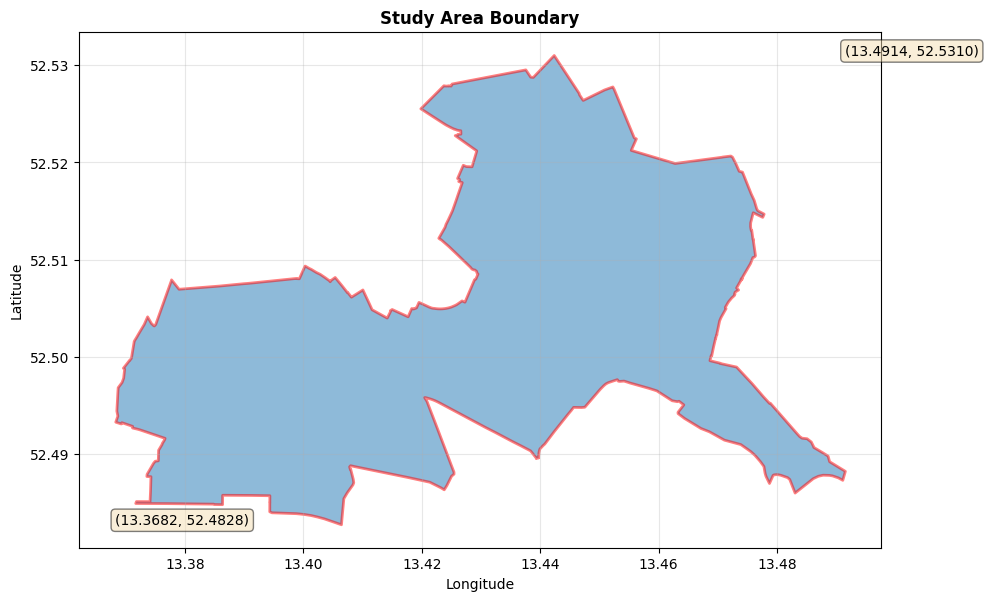

✓ Shapefile boundary visualized!


In [ ]:
"""
Visualize shapefile boundary
"""

import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot shapefile
study_area.plot(ax=ax, alpha=0.5, edgecolor='red', linewidth=2)

# Add labels
ax.set_title('Study Area Boundary', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Add coordinates
bounds = study_area.bounds.iloc[0]
ax.text(bounds.minx, bounds.miny, f"({bounds.minx:.4f}, {bounds.miny:.4f})",
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(bounds.maxx, bounds.maxy, f"({bounds.maxx:.4f}, {bounds.maxy:.4f})",
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Shapefile boundary visualized!")

In [ ]:
import numpy as np
from rasterio.mask import mask
import os

print("="*70)
print("CLIPPING BANDS TO STUDY AREA")
print("="*70)

# Load study area geometry
study_area = gpd.read_file(shapefile_path)

# Reference band for CRS and spatial alignment
# We'll use B08_10m.tif as the reference because it's a 10m band and seems to have the expected shape
reference_band_path = os.path.join(dirs['resampled_data'], 'B08_10m.tif')

if not os.path.exists(reference_band_path):
    print(f"ERROR: Reference band {reference_band_path} not found. Cannot proceed with clipping.")
else:
    with rasterio.open(reference_band_path) as ref_src:
        reference_crs = ref_src.crs
        # Reproject study area to the reference CRS once
        study_area_reprojected = study_area.to_crs(reference_crs)
        geometry = study_area_reprojected.geometry[0]

    print(f"\nUsing reference CRS ({reference_crs}) for clipping.")
    print(f"  Geometry type: {geometry.geom_type}")
    # Correctly format the area units to avoid TypeError
    print(f"  Area: {geometry.area:.6f} {f'{reference_crs.linear_units}²' if reference_crs.linear_units else 'degrees²'}")

    # List all resampled bands
    resampled_files = sorted([f for f in os.listdir(dirs['resampled_data']) if f.endswith('.tif')])

    print(f"\nClipping {len(resampled_files)} bands...")

    for i, input_file in enumerate(resampled_files, 1):
        input_path = os.path.join(dirs['resampled_data'], input_file)
        output_file = input_file.replace('.tif', '_clipped.tif')
        output_path = os.path.join(dirs['clipped_data'], output_file)

        print(f"[{i}/{len(resampled_files)}] Clipping {input_file}...", end=' ')

        try:
            # Read band
            with rasterio.open(input_path) as src:
                # All bands should now be compatible with the reprojected geometry's CRS
                # Clip raster to geometry using the single reprojected geometry
                data, transform = mask(src, [geometry], crop=True)
                profile = src.profile

            # Update profile
            profile.update(
                height=data.shape[1],
                width=data.shape[2],
                transform=transform,
                compress='lzw'
            )

            # Write clipped band
            with rasterio.open(output_path, 'w', **profile) as dst:
                dst.write(data)

            file_size = os.path.getsize(output_path) / 1024 / 1024
            print(f"✓ ({file_size:.1f} MB)")

        except Exception as e:
            print(f"✗ ERROR: {str(e)}")

    print("\n" + "="*70)
    print("✓ ALL BANDS CLIPPED!")
    print("="*70)

    # Verify
    clipped_files = os.listdir(dirs['clipped_data'])
    print(f"\nGenerated {len(clipped_files)} clipped files:")

    total_size = 0
    for f in sorted(clipped_files):
        file_path = os.path.join(dirs['clipped_data'], f)
        file_size = os.path.getsize(file_path) / 1024 / 1024
        total_size += file_size
        print(f"  {f}: {file_size:.1f} MB")

    print(f"\nTotal size: {total_size:.1f} MB")

CLIPPING BANDS TO STUDY AREA

Using reference CRS (EPSG:32632) for clipping.
  Geometry type: Polygon
  Area: 20395717.623112 metre²

Clipping 10 bands...
[1/10] Clipping B02_10m.tif... ✓ (0.4 MB)
[2/10] Clipping B03_10m.tif... ✓ (0.4 MB)
[3/10] Clipping B04_10m.tif... ✓ (0.4 MB)
[4/10] Clipping B05_10m.tif... ✓ (0.9 MB)
[5/10] Clipping B06_10m.tif... ✓ (0.9 MB)
[6/10] Clipping B07_10m.tif... ✓ (0.9 MB)
[7/10] Clipping B08_10m.tif... ✓ (0.5 MB)
[8/10] Clipping B11_10m.tif... ✓ (0.9 MB)
[9/10] Clipping B12_10m.tif... ✓ (0.9 MB)
[10/10] Clipping B8A_10m.tif... ✓ (0.9 MB)

✓ ALL BANDS CLIPPED!

Generated 10 clipped files:
  B02_10m_clipped.tif: 0.4 MB
  B03_10m_clipped.tif: 0.4 MB
  B04_10m_clipped.tif: 0.4 MB
  B05_10m_clipped.tif: 0.9 MB
  B06_10m_clipped.tif: 0.9 MB
  B07_10m_clipped.tif: 0.9 MB
  B08_10m_clipped.tif: 0.5 MB
  B11_10m_clipped.tif: 0.9 MB
  B12_10m_clipped.tif: 0.9 MB
  B8A_10m_clipped.tif: 0.9 MB

Total size: 6.9 MB


Clipped band info:
  Shape: (93, 141)
  Bounds: BoundingBox(left=796440.0, bottom=5823840.0, right=804900.0, top=5829420.0)
  CRS: EPSG:32632

Study area bounds:
  Min X: 13.3682, Max X: 13.4914
  Min Y: 52.4828, Max Y: 52.5310

Clipped band bounds:
  Min X: 796440.0000, Max X: 804900.0000
  Min Y: 5823840.0000, Max Y: 5829420.0000


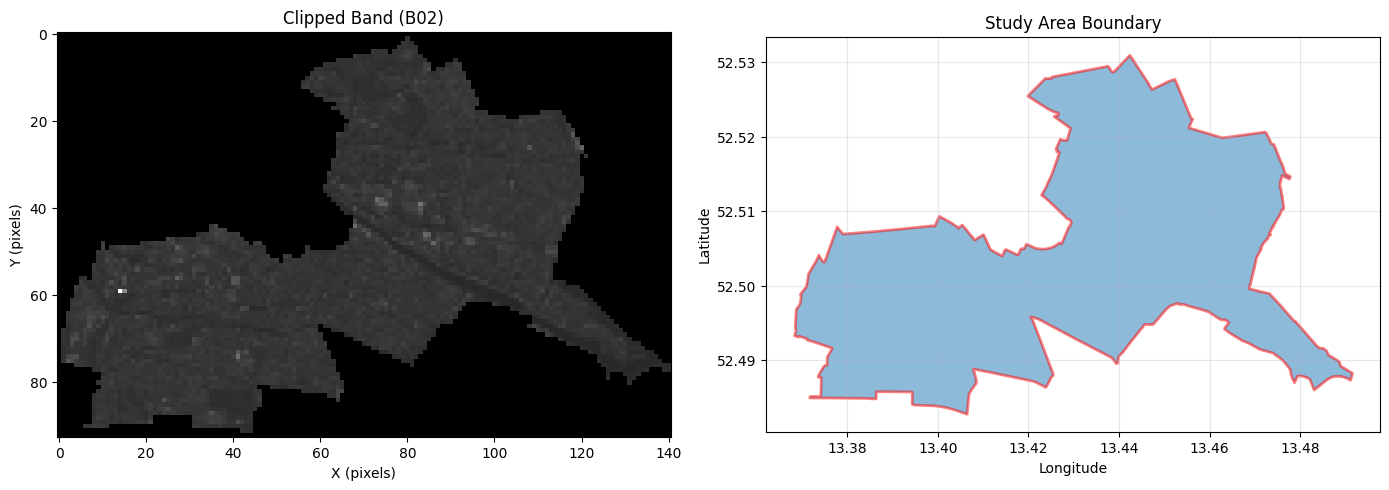


✓ Verification complete!


In [ ]:
"""
Verify clipped bands match study area
"""

# Load one clipped band
clipped_band_path = os.path.join(dirs['clipped_data'], 'B02_10m_clipped.tif')

with rasterio.open(clipped_band_path) as src:
    clipped_data = src.read(1)
    clipped_bounds = src.bounds
    clipped_crs = src.crs

print(f"Clipped band info:")
print(f"  Shape: {clipped_data.shape}")
print(f"  Bounds: {clipped_bounds}")
print(f"  CRS: {clipped_crs}")

# Compare with study area
study_area = gpd.read_file(shapefile_path)
study_bounds = study_area.bounds.iloc[0]

print(f"\nStudy area bounds:")
print(f"  Min X: {study_bounds.minx:.4f}, Max X: {study_bounds.maxx:.4f}")
print(f"  Min Y: {study_bounds.miny:.4f}, Max Y: {study_bounds.maxy:.4f}")

print(f"\nClipped band bounds:")
print(f"  Min X: {clipped_bounds.left:.4f}, Max X: {clipped_bounds.right:.4f}")
print(f"  Min Y: {clipped_bounds.bottom:.4f}, Max Y: {clipped_bounds.top:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot clipped band
axes[0].imshow(clipped_data, cmap='gray')
axes[0].set_title('Clipped Band (B02)')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')

# Plot study area
study_area.plot(ax=axes[1], alpha=0.5, edgecolor='red', linewidth=2)
axes[1].set_title('Study Area Boundary')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Verification complete!")

In [ ]:
import numpy as np
import rasterio
import os

"""
Extract spectral features (bands + indices)
"""

print("="*70)
print("EXTRACTING SPECTRAL FEATURES")
print("="*70)

# Load clipped bands
print("\nLoading clipped bands...")

bands_dict = {}
clipped_files = sorted([f for f in os.listdir(dirs['clipped_data']) if f.endswith('.tif')])

for clipped_file in clipped_files:
    band_name = clipped_file.split('_')[0]
    file_path = os.path.join(dirs['clipped_data'], clipped_file)

    with rasterio.open(file_path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile
        bands_dict[band_name] = data

    print(f"  ✓ Loaded {band_name}: shape={data.shape}")

# Calculate spectral indices
print("\nCalculating spectral indices...")

# NDVI
epsilon = 1e-8
ndvi = (bands_dict['B08'] - bands_dict['B04']) / (bands_dict['B08'] + bands_dict['B04'] + epsilon)
ndvi = np.clip(ndvi, -1, 1)
print(f"  ✓ NDVI: Min={np.nanmin(ndvi):.4f}, Max={np.nanmax(ndvi):.4f}, Mean={np.nanmean(ndvi):.4f}")

# NDBI
ndbi = (bands_dict['B11'] - bands_dict['B08']) / (bands_dict['B11'] + bands_dict['B08'] + epsilon)
ndbi = np.clip(ndbi, -1, 1)
print(f"  ✓ NDBI: Min={np.nanmin(ndbi):.4f}, Max={np.nanmax(ndbi):.4f}, Mean={np.nanmean(ndbi):.4f}")

# NDMI
ndmi = (bands_dict['B08'] - bands_dict['B11']) / (bands_dict['B08'] + bands_dict['B11'] + epsilon)
ndmi = np.clip(ndmi, -1, 1)
print(f"  ✓ NDMI: Min={np.nanmin(ndmi):.4f}, Max={np.nanmax(ndmi):.4f}, Mean={np.nanmean(ndmi):.4f}")

# NDSI
ndsi = (bands_dict['B03'] - bands_dict['B11']) / (bands_dict['B03'] + bands_dict['B11'] + epsilon)
ndsi = np.clip(ndsi, -1, 1)
print(f"  ✓ NDSI: Min={np.nanmin(ndsi):.4f}, Max={np.nanmax(ndsi):.4f}, Mean={np.nanmean(ndsi):.4f}")

# NDRE
ndre = (bands_dict['B08'] - bands_dict['B05']) / (bands_dict['B08'] + bands_dict['B05'] + epsilon)
ndre = np.clip(ndre, -1, 1)
print(f"  ✓ NDRE: Min={np.nanmin(ndre):.4f}, Max={np.nanmax(ndre):.4f}, Mean={np.nanmean(ndre):.4f}")

# MNDWI
mndwi = (bands_dict['B03'] - bands_dict['B12']) / (bands_dict['B03'] + bands_dict['B12'] + epsilon)
mndwi = np.clip(mndwi, -1, 1)
print(f"  ✓ MNDWI: Min={np.nanmin(mndwi):.4f}, Max={np.nanmax(mndwi):.4f}, Mean={np.nanmean(mndwi):.4f}")

print("\n✓ All spectral indices calculated!")

EXTRACTING SPECTRAL FEATURES

Loading clipped bands...
  ✓ Loaded B02: shape=(553, 841)
  ✓ Loaded B03: shape=(553, 841)
  ✓ Loaded B04: shape=(553, 841)
  ✓ Loaded B05: shape=(553, 841)
  ✓ Loaded B06: shape=(553, 841)
  ✓ Loaded B07: shape=(553, 841)
  ✓ Loaded B08: shape=(553, 841)
  ✓ Loaded B11: shape=(553, 841)
  ✓ Loaded B12: shape=(553, 841)
  ✓ Loaded B8A: shape=(553, 841)

Calculating spectral indices...
  ✓ NDVI: Min=-1.0000, Max=1.0000, Mean=0.0407
  ✓ NDBI: Min=-0.5706, Max=1.0000, Mean=0.0040
  ✓ NDMI: Min=-1.0000, Max=0.5706, Mean=-0.0040
  ✓ NDSI: Min=-0.7943, Max=0.5559, Mean=-0.0490
  ✓ NDRE: Min=-1.0000, Max=0.4548, Mean=0.0200
  ✓ MNDWI: Min=-0.6882, Max=0.6851, Mean=-0.0285

✓ All spectral indices calculated!


In [ ]:
"""
Stack all features into single array
"""

print("\nStacking features...")

# Create feature list
features_list = [
    bands_dict['B02'],    # Blue
    bands_dict['B03'],    # Green
    bands_dict['B04'],    # Red
    bands_dict['B08'],    # NIR
    bands_dict['B11'],    # SWIR
    bands_dict['B12'],    # SWIR2
    ndvi,                 # NDVI
    ndbi,                 # NDBI
    ndmi,                 # NDMI
    ndsi,                 # NDSI
    ndre,                 # NDRE
    mndwi,                # MNDWI
]

# Stack into single array
feature_stack = np.stack(features_list, axis=0)

print(f"✓ Feature stack created!")
print(f"  Shape: {feature_stack.shape}")
print(f"  Dimensions: {feature_stack.shape[0]} features × {feature_stack.shape[1]} rows × {feature_stack.shape[2]} columns")
print(f"  Memory size: {feature_stack.nbytes / 1024 / 1024:.2f} MB")

# Save feature stack
feature_stack_path = os.path.join(dirs['spectral_features'], 'features_stacked.npy')
np.save(feature_stack_path, feature_stack)
print(f"\n✓ Feature stack saved: {feature_stack_path}")


Stacking features...
✓ Feature stack created!
  Shape: (12, 553, 841)
  Dimensions: 12 features × 553 rows × 841 columns
  Memory size: 21.29 MB

✓ Feature stack saved: /content/drive/My Drive/WorkflowB/spectral_features/features_stacked.npy


In [ ]:
# CELL 8: LOAD GPS & EXTRACT TRAINING DATA (FINAL)
# Uses your GPS CSV with actual structure

import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import rowcol
import os
import geopandas as gpd # Import geopandas for reprojection

print("="*70)
print("STEP 1: LOAD GPS & EXTRACT TRAINING DATA")
print("="*70)

# Explicitly define base_dir and dirs for this cell to ensure robustness
# against runtime resets or inadvertent variable overwrites from other cells.
base_dir = '/content/drive/My Drive/WorkflowB' # Ensure base_dir is defined
dirs = {
    'raw_data': f'{base_dir}/raw_data',
    'converted_tif': f'{base_dir}/converted_tif',
    'resampled_data': f'{base_dir}/resampled_data',
    'clipped_data': f'{base_dir}/clipped_data',
    'spectral_features': f'{base_dir}/spectral_features',
    'training_data': f'{base_dir}/training_data',
    'models': f'{base_dir}/models',
    'results': f'{base_dir}/results'
}
print("✓ Defined working directories within this cell.")

# Load feature stack
feature_stack_path = os.path.join(dirs['spectral_features'], 'features_stacked.npy')
feature_stack = np.load(feature_stack_path)
print(f"\n✓ Loaded feature stack: {feature_stack.shape}")

# Load reference band for geotransform
reference_band_path = os.path.join(dirs['clipped_data'], 'B02_10m_clipped.tif')
with rasterio.open(reference_band_path) as src:
    transform = src.transform
    crs = src.crs
    bounds = src.bounds # Store bounds for checking if needed

print(f"✓ Reference CRS: {crs}")

# Load GPS from CSV
print("\nLoading GPS from CSV...")
gps_csv_path = '/content/drive/My Drive/WorkflowB/GPS extract/gps_within_study_area.csv'

try:
    gps_df = pd.read_csv(gps_csv_path)
    print(f"✓ Loaded GPS from CSV: {len(gps_df)} locations")
    print(f"\nColumns: {list(gps_df.columns)}")
    print(f"\nFirst few rows:")
    print(gps_df.head())
except Exception as e:
    print(f"ERROR: Could not load GPS CSV: {e}")

# Check class distribution
print(f"\n✓ Class distribution in CSV:")
print(gps_df['class_name'].value_counts())

STEP 1: LOAD GPS & EXTRACT TRAINING DATA
✓ Defined working directories within this cell.

✓ Loaded feature stack: (12, 553, 841)
✓ Reference CRS: EPSG:32632

Loading GPS from CSV...
✓ Loaded GPS from CSV: 1290 locations

Columns: ['image_name', 'image_path', 'class_id', 'class_name', 'latitude', 'longitude']

First few rows:
       image_name                                         image_path  \
0  IMG_0620 2.JPG  /content/SLI_extracted/SLI/Commercial_Industri...   
1  IMG_0629 2.JPG  /content/SLI_extracted/SLI/Commercial_Industri...   
2  IMG_0630 2.JPG  /content/SLI_extracted/SLI/Commercial_Industri...   
3  IMG_0642 2.jpg  /content/SLI_extracted/SLI/Commercial_Industri...   
4  IMG_0647 2.jpg  /content/SLI_extracted/SLI/Commercial_Industri...   

   class_id                                      class_name   latitude  \
0         2  Commercial/Industrial/L-Scale Retail/Logistics  52.507064   
1         2  Commercial/Industrial/L-Scale Retail/Logistics  52.505797   
2         2  Comme

In [ ]:
# ============================================================
# IMPORTANT: Choose class mapping (3 classes or 5 classes)
# ============================================================

# OPTION 1: Use 3 classes (to match Workflow A)
# Consolidate to: Residential, Commercial, Public/Institutional
class_mapping_3 = {
    'Residential/Mixed Use': 0,
    'Commercial/Industrial/L-Scale Retail/Logistics': 1,
    'Public Use/Institutional/Core Area': 1,
    'Transportation and infrastructure': 1,
    'Others/Unclassified': 1
}

# OPTION 2: Use 5 classes (more detailed)
class_mapping_5 = {
    'Residential/Mixed Use': 0,
    'Public Use/Institutional/Core Area': 1,
    'Commercial/Industrial/L-Scale Retail/Logistics': 2,
    'Transportation and infrastructure': 3,
    'Others/Unclassified': 4
}

# SELECT WHICH MAPPING TO USE (change this line)
USE_3_CLASSES = False  # Set to False to use 5 classes

if USE_3_CLASSES:
    class_mapping = class_mapping_3
    n_classes = 3
    class_names = ['Residential', 'Commercial/Public', 'Unclassified']
    print(f"\n✓ Using 3-class mapping (to match Workflow A)")
else:
    class_mapping = class_mapping_5
    n_classes = 5
    class_names = ['Residential', 'Public', 'Commercial', 'Transportation', 'Others']
    print(f"\n✓ Using 5-class mapping (more detailed)")

# Map class names to numeric labels
gps_df['label'] = gps_df['class_name'].map(class_mapping)

# Check for unmapped classes
unmapped = gps_df[gps_df['label'].isna()]
if len(unmapped) > 0:
    print(f"\n⚠ WARNING: {len(unmapped)} rows have unmapped classes:")
    print(unmapped['class_name'].unique())
    gps_df = gps_df.dropna(subset=['label'])
    print(f"✓ Removed unmapped rows. Remaining: {len(gps_df)}")

print(f"\n✓ GPS data ready: {len(gps_df)} labeled locations")
print(f"\nClass distribution after mapping:")
for class_id in sorted(gps_df['label'].unique()):
    count = np.sum(gps_df['label'] == class_id)
    pct = 100 * count / len(gps_df)
    print(f"  Class {int(class_id)}: {count} samples ({pct:.1f}%)")

# Convert GPS to pixel coordinates
def gps_to_pixel(x_coord, y_coord, transform):
    """Convert projected coordinates (e.g., UTM easting, northing) to pixel coordinates"""
    row, col = rowcol(transform, x_coord, y_coord)
    return int(row), int(col)

print("\nConverting GPS to pixel coordinates...")

# Reproject GPS points to the raster's CRS
print(f"Reprojecting GPS points from EPSG:4326 to {crs}...")
gps_gdf = gpd.GeoDataFrame(
    gps_df,
    geometry=gpd.points_from_xy(gps_df['longitude'], gps_df['latitude']),
    crs="EPSG:4326"
)
gps_gdf_reprojected = gps_gdf.to_crs(crs)
print(f"✓ GPS points reprojected. First point geometry: {gps_gdf_reprojected.geometry.iloc[0]}")


training_features = []
training_labels = []
valid_samples = 0
out_of_bounds = 0
nan_values = 0

for idx, row in gps_gdf_reprojected.iterrows(): # Iterate over reprojected GeoDataFrame
    try:
        # Convert projected coordinates (easting, northing) to pixel
        pixel_row, pixel_col = gps_to_pixel(
            row.geometry.x, # Easting
            row.geometry.y, # Northing
            transform
        )

        # Check if pixel is within bounds
        if (0 <= pixel_row < feature_stack.shape[1] and
            0 <= pixel_col < feature_stack.shape[2]):

            # Extract 12 features at this pixel
            features = feature_stack[:, pixel_row, pixel_col]

            # Skip if any NaN values
            if not np.isnan(features).any():
                training_features.append(features)
                training_labels.append(int(row['label']))
                valid_samples += 1
            else:
                nan_values += 1
        else:
            out_of_bounds += 1
    except Exception as e: # Catch specific exceptions for better debugging
        print(f"Error processing row {idx}: {e}")
        pass

# Convert to numpy arrays
X_train = np.array(training_features)
y_train = np.array(training_labels)

print(f"\n✓ Extracted {valid_samples} valid training samples")
print(f"  Shape: {X_train.shape}")
print(f"  Out of bounds: {out_of_bounds}")
print(f"  NaN values: {nan_values}")

# Save training data
training_data_path = os.path.join(dirs['training_data'], 'training_data.npz')
os.makedirs(os.path.dirname(training_data_path), exist_ok=True) # Ensure directory exists before saving
np.savez(training_data_path, X=X_train, y=y_train)
print(f"\n✓ Training data saved: {training_data_path}")

# Summary statistics
print(f"\nTraining data summary:")
print(f"  Total samples: {len(X_train)}")
# Only print features per sample if X_train is not empty
if X_train.shape[0] > 0:
    print(f"  Features per sample: {X_train.shape[1]}")
else:
    print(f"  No valid training samples, so no features per sample.")

print(f"  Classes: {np.unique(y_train)}")
print(f"  Class distribution:")
if len(y_train) > 0:
    for class_id in np.unique(y_train):
        count = np.sum(y_train == class_id)
        pct = 100 * count / len(y_train)
        print(f"    Class {int(class_id)}: {count} samples ({pct:.1f}%)")
else:
    print("    No training labels to display class distribution.")

print(f"\n✓ STEP 1 COMPLETE!")


✓ Using 5-class mapping (more detailed)

✓ GPS data ready: 1290 labeled locations

Class distribution after mapping:
  Class 0: 634 samples (49.1%)
  Class 1: 158 samples (12.2%)
  Class 2: 355 samples (27.5%)
  Class 3: 86 samples (6.7%)
  Class 4: 57 samples (4.4%)

Converting GPS to pixel coordinates...
Reprojecting GPS points from EPSG:4326 to EPSG:32632...
✓ GPS points reprojected. First point geometry: POINT (802955.913074408 5826811.636504655)

✓ Extracted 1290 valid training samples
  Shape: (1290, 12)
  Out of bounds: 0
  NaN values: 0

✓ Training data saved: /content/drive/My Drive/WorkflowB/training_data/training_data.npz

Training data summary:
  Total samples: 1290
  Features per sample: 12
  Classes: [0 1 2 3 4]
  Class distribution:
    Class 0: 634 samples (49.1%)
    Class 1: 158 samples (12.2%)
    Class 2: 355 samples (27.5%)
    Class 3: 86 samples (6.7%)
    Class 4: 57 samples (4.4%)

✓ STEP 1 COMPLETE!


In [ ]:
# CELL 9: TRAIN RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight
import pickle
import json

print("="*70)
print("STEP 2: TRAIN RANDOM FOREST CLASSIFIER")
print("="*70)

# Load training data
training_data_path = os.path.join(dirs['training_data'], 'training_data.npz')
data = np.load(training_data_path)
X = data['X']
y = data['y']

print(f"\n✓ Loaded training data: {X.shape}")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

# Calculate class weights for imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights: {class_weight_dict}")

# Train Random Forest
print("\nTraining Random Forest...")
print("  n_estimators: 100")
print("  max_depth: 15")
print("  min_samples_split: 10")
print("  min_samples_leaf: 5")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("✓ Training complete!")

# Evaluate on training set
y_train_pred = rf_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_kappa = cohen_kappa_score(y_train, y_train_pred)

print(f"\nTraining metrics:")
print(f"  Accuracy: {train_acc:.4f}")
print(f"  Weighted F1: {train_f1:.4f}")
print(f"  Cohen's Kappa: {train_kappa:.4f}")

# Evaluate on test set
y_test_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_kappa = cohen_kappa_score(y_test, y_test_pred)

print(f"\nTest metrics:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Weighted F1: {test_f1:.4f}")
print(f"  Cohen's Kappa: {test_kappa:.4f}")

# Per-class metrics
print(f"\nPer-class metrics:")
# Corrected class_names to match the 5 classes used in the data
class_names = ['Residential', 'Public', 'Commercial', 'Transportation', 'Others']
print(classification_report(y_test, y_test_pred,
                           target_names=class_names[:len(np.unique(y_test))]))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion matrix:")
print(cm)

# Feature importance
feature_names = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12',
                 'NDVI', 'NDBI', 'NDMI', 'NDSI', 'NDRE', 'MNDWI']
feature_importance = rf_model.feature_importances_

print(f"\nFeature importance (top 6):")
top_indices = np.argsort(feature_importance)[::-1][:6]
for idx in top_indices:
    print(f"  {feature_names[idx]}: {feature_importance[idx]:.4f}")

# Save model
model_path = os.path.join(dirs['models'], 'random_forest_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f"\n✓ Model saved: {model_path}")

# Save metrics
metrics = {
    'train_accuracy': float(train_acc),
    'train_f1': float(train_f1),
    'train_kappa': float(train_kappa),
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_kappa': float(test_kappa),
    'confusion_matrix': cm.tolist(),
    'feature_importance': feature_importance.tolist()
}

metrics_path = os.path.join(dirs['results'], 'rf_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrics saved: {metrics_path}")

print(f"\n✓ STEP 2 COMPLETE!")


STEP 2: TRAIN RANDOM FOREST CLASSIFIER

✓ Loaded training data: (1290, 12)

Data split:
  Training: 1032 samples
  Testing: 258 samples

Class weights: {0: np.float64(0.40710059171597635), 1: np.float64(1.638095238095238), 2: np.float64(0.7267605633802817), 3: np.float64(2.991304347826087), 4: np.float64(4.48695652173913)}

Training Random Forest...
  n_estimators: 100
  max_depth: 15
  min_samples_split: 10
  min_samples_leaf: 5
✓ Training complete!

Training metrics:
  Accuracy: 0.9070
  Weighted F1: 0.9079
  Cohen's Kappa: 0.8624

Test metrics:
  Accuracy: 0.7054
  Weighted F1: 0.7057
  Cohen's Kappa: 0.5615

Per-class metrics:
                precision    recall  f1-score   support

   Residential       0.80      0.74      0.77       127
        Public       0.57      0.84      0.68        32
    Commercial       0.66      0.66      0.66        71
Transportation       0.77      0.59      0.67        17
        Others       0.44      0.36      0.40        11

      accuracy         

### Visualize Model Performance Metrics

Overall Model Metrics:


,Metric,Train,Test
0,Accuracy,0.906977,0.705426
1,Weighted F1,0.907946,0.705658
2,Cohen's Kappa,0.862410,0.561470


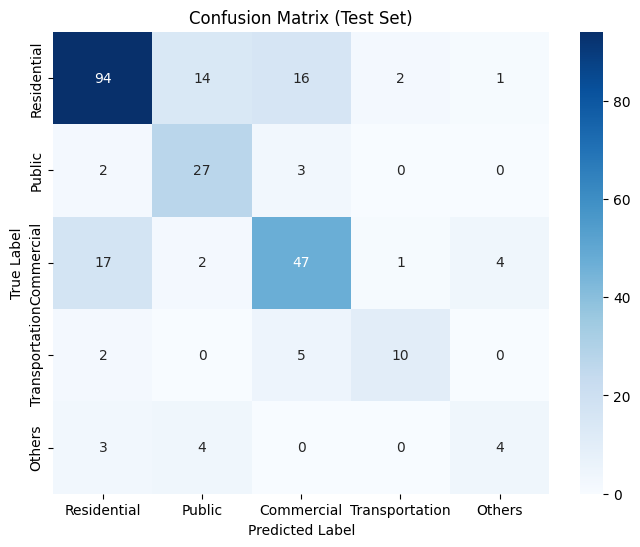

/tmp/ipython-input-250889207.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


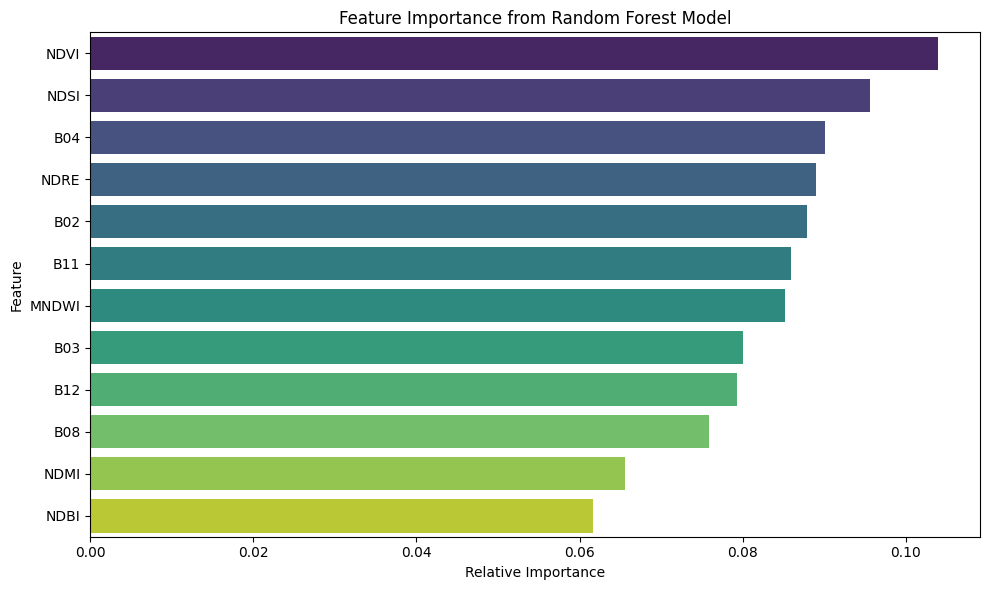


✓ Visualizations generated!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pandas as pd
import numpy as np

# Ensure dirs is defined for standalone execution
if 'dirs' not in globals():
    print("WARNING: 'dirs' variable not found. Defining it for this cell.")
    base_dir = '/content/drive/My Drive/WorkflowB'
    dirs = {
        'raw_data': f'{base_dir}/raw_data',
        'converted_tif': f'{base_dir}/converted_tif',
        'resampled_data': f'{base_dir}/resampled_data',
        'clipped_data': f'{base_dir}/clipped_data',
        'spectral_features': f'{base_dir}/spectral_features',
        'training_data': f'{base_dir}/training_data',
        'models': f'{base_dir}/models',
        'results': f'{base_dir}/results'
    }

# Load metrics
metrics_path = os.path.join(dirs['results'], 'rf_metrics.json')
with open(metrics_path, 'r') as f:
    metrics = json.load(f)

# Display overall metrics
print("Overall Model Metrics:")
overall_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted F1', 'Cohen\'s Kappa'],
    'Train': [metrics['train_accuracy'], metrics['train_f1'], metrics['train_kappa']],
    'Test': [metrics['test_accuracy'], metrics['test_f1'], metrics['test_kappa']]
})
display(overall_metrics_df)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = np.array(metrics['confusion_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Plot Feature Importance
plt.figure(figsize=(10, 6))
feature_names = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12',
                 'NDVI', 'NDBI', 'NDMI', 'NDSI', 'NDRE', 'MNDWI']
feature_importance = np.array(metrics['feature_importance'])

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n✓ Visualizations generated!")

To save these plots directly, you can modify the visualization cell to explicitly save them as image files. Here's how you can save the confusion matrix and feature importance plots:

Overall Model Metrics:


,Metric,Train,Test
0,Accuracy,0.906977,0.705426
1,Weighted F1,0.907946,0.705658
2,Cohen's Kappa,0.862410,0.561470


✓ Confusion matrix saved to: /content/drive/My Drive/WorkflowB/results/confusion_matrix.png


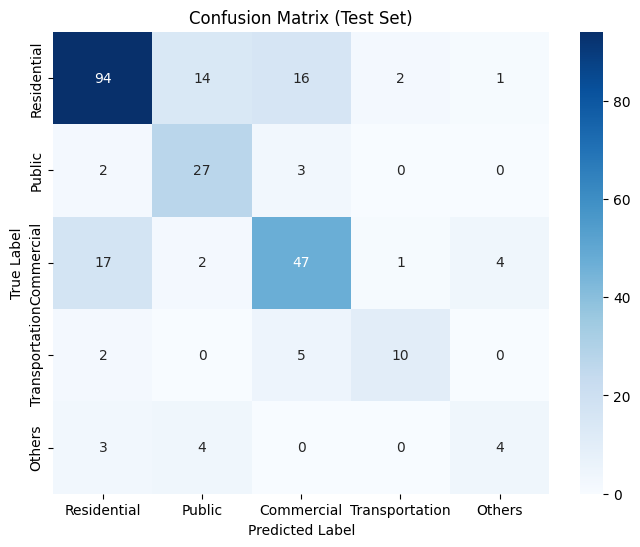

/tmp/ipython-input-2669697276.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


✓ Feature importance plot saved to: /content/drive/My Drive/WorkflowB/results/feature_importance.png


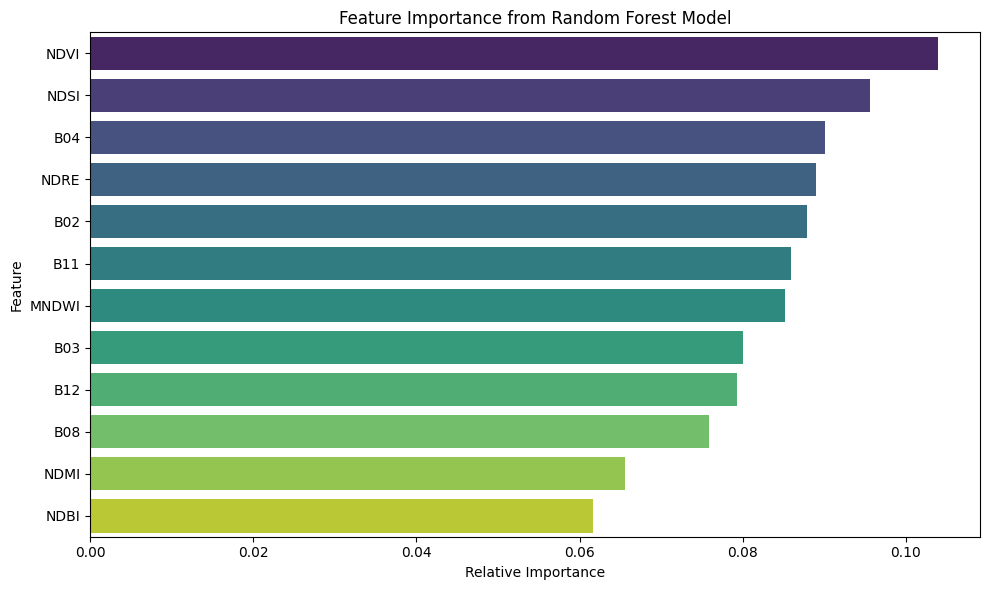


✓ Visualizations generated and saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import pandas as pd
import numpy as np

# Ensure dirs is defined for standalone execution
if 'dirs' not in globals():
    print("WARNING: 'dirs' variable not found. Defining it for this cell.")
    base_dir = '/content/drive/My Drive/WorkflowB'
    dirs = {
        'raw_data': f'{base_dir}/raw_data',
        'converted_tif': f'{base_dir}/converted_tif',
        'resampled_data': f'{base_dir}/resampled_data',
        'clipped_data': f'{base_dir}/clipped_data',
        'spectral_features': f'{base_dir}/spectral_features',
        'training_data': f'{base_dir}/training_data',
        'models': f'{base_dir}/models',
        'results': f'{base_dir}/results'
    }

# Load metrics
metrics_path = os.path.join(dirs['results'], 'rf_metrics.json')
with open(metrics_path, 'r') as f:
    metrics = json.load(f)

# Display overall metrics
print("Overall Model Metrics:")
overall_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted F1', 'Cohen\'s Kappa'],
    'Train': [metrics['train_accuracy'], metrics['train_f1'], metrics['train_kappa']],
    'Test': [metrics['test_accuracy'], metrics['test_f1'], metrics['test_kappa']]
})
display(overall_metrics_df)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = np.array(metrics['confusion_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')

# Save Confusion Matrix plot
confusion_matrix_path = os.path.join(dirs['results'], 'confusion_matrix.png')
plt.savefig(confusion_matrix_path)
print(f"✓ Confusion matrix saved to: {confusion_matrix_path}")
plt.show()

# Plot Feature Importance
plt.figure(figsize=(10, 6))
feature_names = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12',
                 'NDVI', 'NDBI', 'NDMI', 'NDSI', 'NDRE', 'MNDWI']
feature_importance = np.array(metrics['feature_importance'])

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()

# Save Feature Importance plot
feature_importance_path = os.path.join(dirs['results'], 'feature_importance.png')
plt.savefig(feature_importance_path)
print(f"✓ Feature importance plot saved to: {feature_importance_path}")
plt.show()

print("\n✓ Visualizations generated and saved!")

STEP 3: GENERATE PREDICTIONS
✓ Loaded model: /content/drive/My Drive/WorkflowB/models/random_forest_model.pkl
✓ Loaded feature stack: (12, 553, 841)

Predicting land use for 465073 pixels...
✓ Predictions complete!
  Classification map shape: (553, 841)

✓ Classification map saved: /content/drive/My Drive/WorkflowB/results/classification_map.npy
✓ Confidence map saved: /content/drive/My Drive/WorkflowB/results/confidence_map.npy

Class distribution in predictions:
  Class 0: 68707 pixels (14.8%)
  Class 1: 44656 pixels (9.6%)
  Class 2: 323445 pixels (69.5%)
  Class 3: 14885 pixels (3.2%)
  Class 4: 13380 pixels (2.9%)

✓ Visualization saved: classification_and_confidence.png


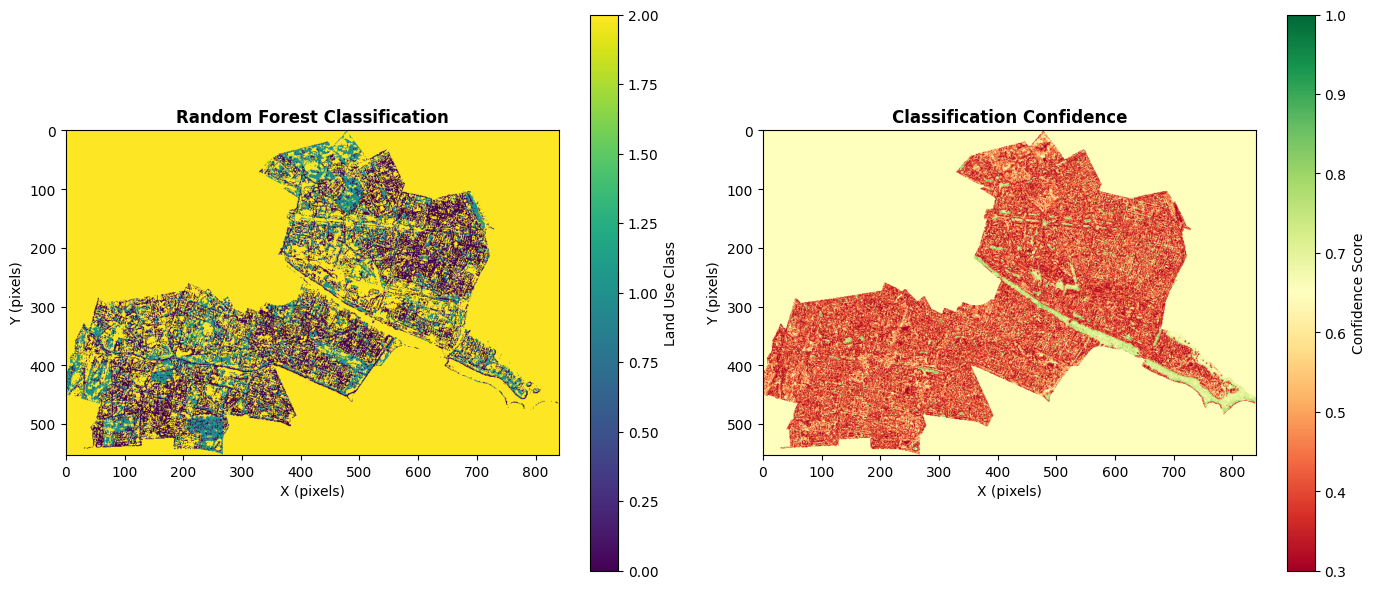


✓ STEP 3 COMPLETE!
✓ Loaded classification map with shape: (553, 841)
✓ Improved classification map saved to: /content/drive/My Drive/WorkflowB/results/classification_map_improved.png


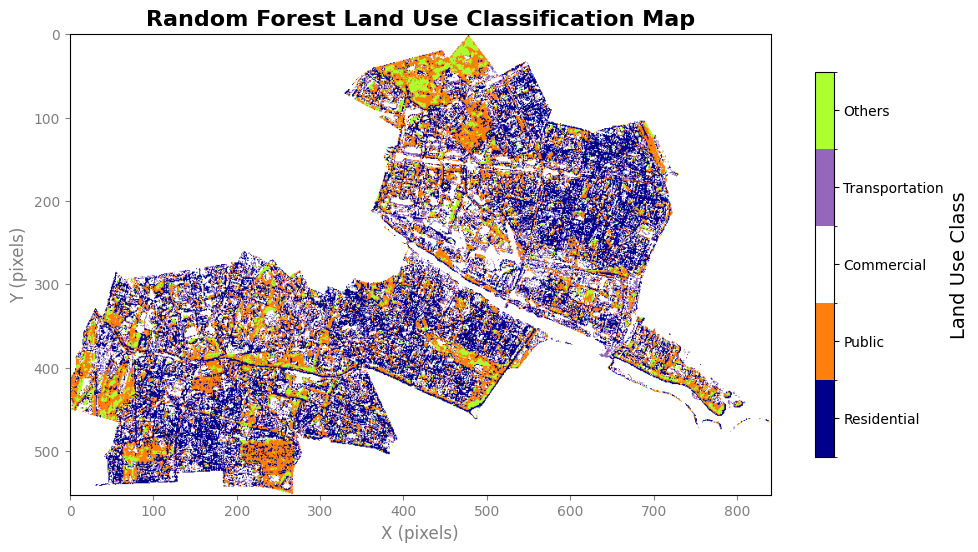

✓ Classification map displayed successfully!


/tmp/ipython-input-3133713035.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=overall_metrics_df, palette='viridis')


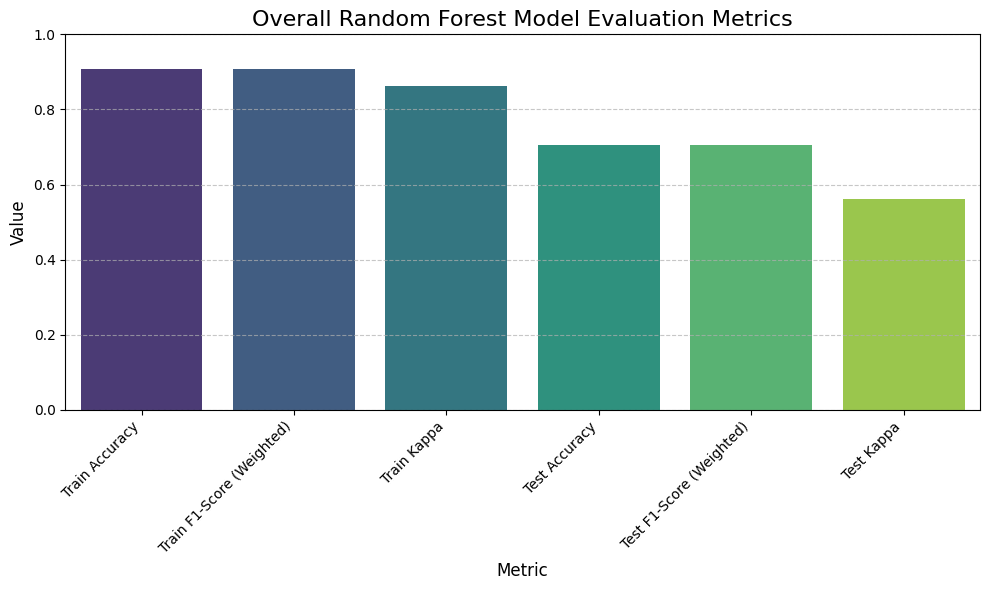


✓ Overall model metrics visualization complete!


/tmp/ipython-input-3133713035.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Precision', data=per_class_metrics_df, ax=axes[0], palette='Blues_d')
/tmp/ipython-input-3133713035.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Recall', data=per_class_metrics_df, ax=axes[1], palette='Greens_d')
/tmp/ipython-input-3133713035.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='F1-Score', data=per_class_metrics_df, ax=axes[2], palette='Reds_d')


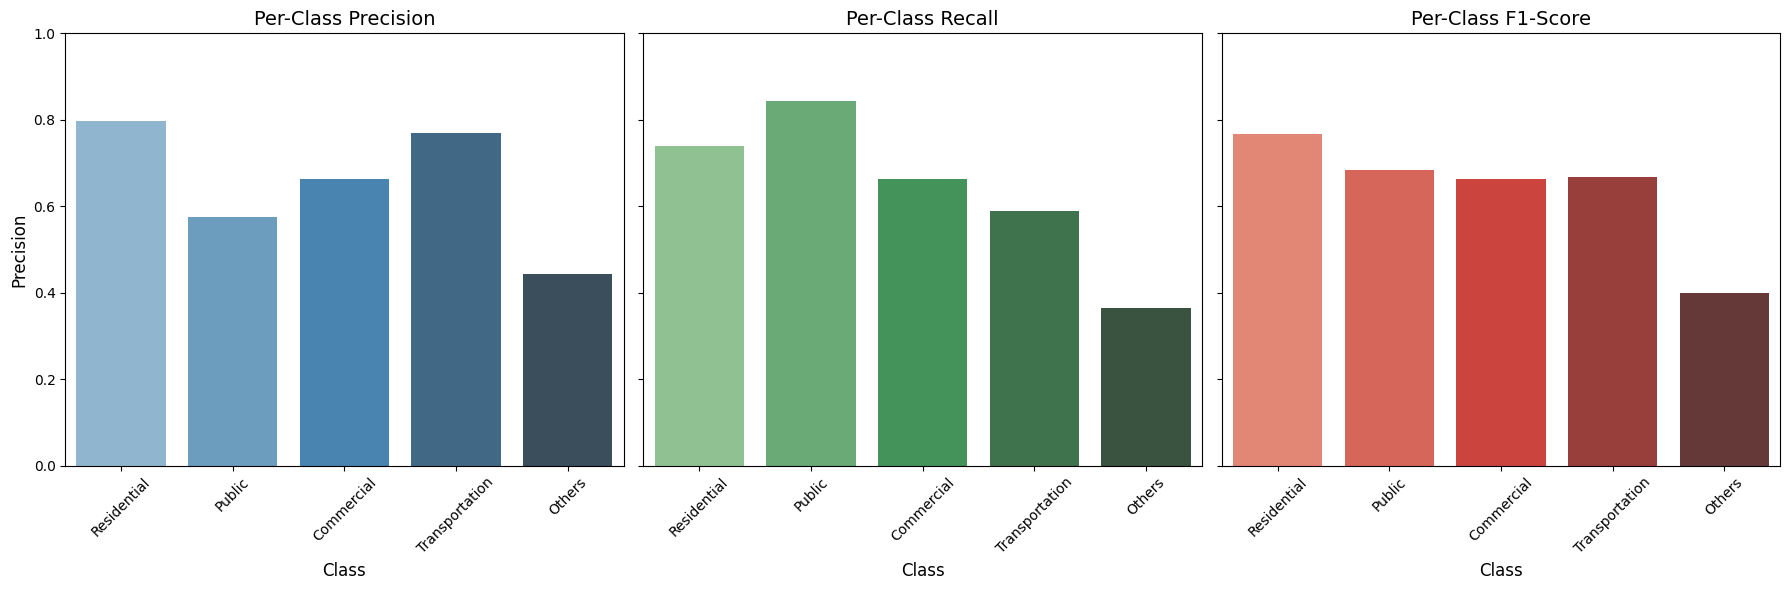


✓ Per-class metrics visualization complete!


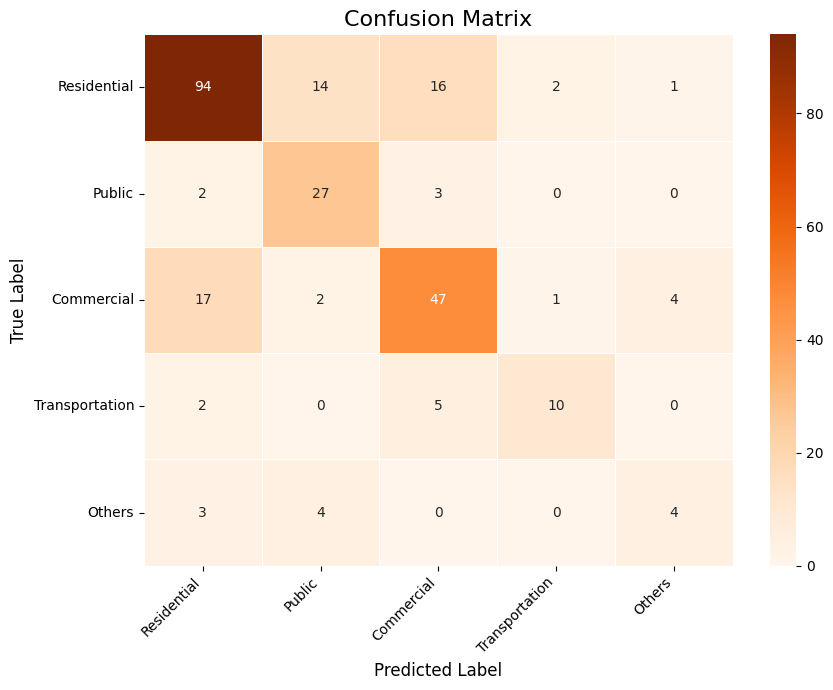


✓ Confusion matrix visualization complete!
STEP 4: SAVE MODEL EVALUATION METRICS TO CSV


In [ ]:
# CELL 10: GENERATE PREDICTIONS

import pickle
import matplotlib.pyplot as plt

print("="*70)
print("STEP 3: GENERATE PREDICTIONS")
print("="*70)

# Load model
model_path = os.path.join(dirs['models'], 'random_forest_model.pkl')
with open(model_path, 'rb') as f:
    rf_model = pickle.load(f)

print(f"✓ Loaded model: {model_path}")

# Load feature stack
feature_stack_path = os.path.join(dirs['spectral_features'], 'features_stacked.npy')
feature_stack = np.load(feature_stack_path)

print(f"✓ Loaded feature stack: {feature_stack.shape}")

# Reshape feature stack for prediction
n_features, height, width = feature_stack.shape
X_predict = feature_stack.reshape(n_features, -1).T  # (H*W, 12)

print(f"\nPredicting land use for {X_predict.shape[0]} pixels...")

# Generate predictions
y_predict = rf_model.predict(X_predict)
y_predict_proba = rf_model.predict_proba(X_predict)

# Reshape to original dimensions
classification_map = y_predict.reshape(height, width)
confidence_map = np.max(y_predict_proba, axis=1).reshape(height, width)

print(f"✓ Predictions complete!")
print(f"  Classification map shape: {classification_map.shape}")

# Save classification map
classification_map_path = os.path.join(dirs['results'], 'classification_map.npy')
np.save(classification_map_path, classification_map)
print(f"\n✓ Classification map saved: {classification_map_path}")

# Save confidence map
confidence_map_path = os.path.join(dirs['results'], 'confidence_map.npy')
np.save(confidence_map_path, confidence_map)
print(f"✓ Confidence map saved: {confidence_map_path}")

# Class distribution in predictions
unique, counts = np.unique(classification_map, return_counts=True)
print(f"\nClass distribution in predictions:")
class_names = ['Residential', 'Commercial/Public', 'Unclassified']
total_pixels = height * width

for class_id, count in zip(unique, counts):
    pct = 100 * count / total_pixels
    print(f"  Class {int(class_id)}: {count} pixels ({pct:.1f}%)")

# Visualize classification map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Classification map
im1 = axes[0].imshow(classification_map, cmap='viridis', vmin=0, vmax=2)
axes[0].set_title('Random Forest Classification', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Land Use Class')

# Confidence map
im2 = axes[1].imshow(confidence_map, cmap='RdYlGn', vmin=0.3, vmax=1.0)
axes[1].set_title('Classification Confidence', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X (pixels)')
axes[1].set_ylabel('Y (pixels)')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Confidence Score')

plt.tight_layout()
plt.savefig(os.path.join(dirs['results'], 'classification_and_confidence.png'), dpi=150)
print(f"\n✓ Visualization saved: classification_and_confidence.png")
plt.show()

print(f"\n✓ STEP 3 COMPLETE!")

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

# Define class names to match the 5 classes used in the model
class_names_5_classes = ['Residential', 'Public', 'Commercial', 'Transportation', 'Others']

# Load the classification map
classification_map_path = os.path.join(dirs['results'], 'classification_map.npy')
classification_map = np.load(classification_map_path)

print(f"✓ Loaded classification map with shape: {classification_map.shape}")

# Define a custom colormap with 5 distinct colors that contrast well with white
# Residential (index 0) set to orange, Public (index 1) set to deep blue, Commercial (index 2) set to white
# Transportation (index 3) set to purple, Others (index 4) set to lemon green
custom_colors = ['#00008B', '#ff7f0e', '#FFFFFF', '#9467bd', '#ADFF2F']
custom_cmap = mcolors.ListedColormap(custom_colors)

# Ensure that each integer class value maps to a distinct color
bounds = np.arange(len(class_names_5_classes) + 1) # [0, 1, 2, 3, 4, 5]
norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

# Visualize the classification map with improvements
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white') # Set figure background to white
ax.set_facecolor('white') # Set axes background to white

# Use the custom colormap and norm for discrete mapping
im = ax.imshow(classification_map, cmap=custom_cmap, norm=norm)

ax.set_title('Random Forest Land Use Classification Map', fontsize=16, fontweight='bold', color='black') # Improve title readability
ax.set_xlabel('X (pixels)', fontsize=12, color='gray')
ax.set_ylabel('Y (pixels)', fontsize=12, color='gray')
ax.tick_params(axis='x', colors='gray') # Change tick color
ax.tick_params(axis='y', colors='gray')

# Create colorbar with custom labels, reduced size using shrink
# Ticks should be centered on the color blocks. For N colors, ticks are at 0.5, 1.5, ..., N-0.5
cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(class_names_5_classes)) + 0.5, shrink=0.5)
cbar.set_label('Land Use Class', fontsize=14, color='black')
cbar.set_ticklabels(class_names_5_classes)
cbar.ax.tick_params(colors='black')

plt.tight_layout()

# Save the improved visualization
output_filename = os.path.join(dirs['results'], 'classification_map_improved.png')
plt.savefig(output_filename, dpi=300, facecolor=fig.get_facecolor())
print(f"✓ Improved classification map saved to: {output_filename}")

plt.show()

print("✓ Classification map displayed successfully!")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# --- Visualize Overall Model Metrics ---
overall_metrics_csv_path = os.path.join(dirs['results'], 'overall_model_metrics.csv')
overall_metrics_df = pd.read_csv(overall_metrics_csv_path)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=overall_metrics_df, palette='viridis')
plt.title('Overall Random Forest Model Evaluation Metrics', fontsize=16)
plt.ylabel('Value', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n✓ Overall model metrics visualization complete!")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# --- Visualize Per-Class Metrics ---
per_class_metrics_csv_path = os.path.join(dirs['results'], 'per_class_model_metrics.csv')
per_class_metrics_df = pd.read_csv(per_class_metrics_csv_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.barplot(x='Class', y='Precision', data=per_class_metrics_df, ax=axes[0], palette='Blues_d')
axes[0].set_title('Per-Class Precision', fontsize=14)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Class', y='Recall', data=per_class_metrics_df, ax=axes[1], palette='Greens_d')
axes[1].set_title('Per-Class Recall', fontsize=14)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x='Class', y='F1-Score', data=per_class_metrics_df, ax=axes[2], palette='Reds_d')
axes[2].set_title('Per-Class F1-Score', fontsize=14)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Per-class metrics visualization complete!")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# --- Visualize Confusion Matrix ---
confusion_matrix_csv_path = os.path.join(dirs['results'], 'confusion_matrix.csv')
cm_df = pd.read_csv(confusion_matrix_csv_path, index_col=0)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Oranges', cbar=True, linewidths=.5)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✓ Confusion matrix visualization complete!")

import pandas as pd
import numpy as np
import os
from sklearn.metrics import precision_recall_fscore_support, classification_report

print("="*70)
print("STEP 4: SAVE MODEL EVALUATION METRICS TO CSV")
print("="*70)

In [ ]:
# --- 1. Load Metrics from JSON ---
metrics_path = os.path.join(dirs['results'], 'rf_metrics.json')
with open(metrics_path, 'r') as f:
    metrics_dict = json.load(f)

print(f"\n✓ Loaded metrics from: {metrics_path}")

# --- 2. Overall Model Metrics ---
overall_metrics_data = {
    'Metric': ['Train Accuracy', 'Train F1-Score (Weighted)', 'Train Kappa',
               'Test Accuracy', 'Test F1-Score (Weighted)', 'Test Kappa'],
    'Value': [
        metrics_dict['train_accuracy'],
        metrics_dict['train_f1'],
        metrics_dict['train_kappa'],
        metrics_dict['test_accuracy'],
        metrics_dict['test_f1'],
        metrics_dict['test_kappa']
    ]
}
overall_metrics_df = pd.DataFrame(overall_metrics_data)

overall_metrics_csv_path = os.path.join(dirs['results'], 'overall_model_metrics.csv')
overall_metrics_df.to_csv(overall_metrics_csv_path, index=False)
print(f"✓ Overall model metrics saved to: {overall_metrics_csv_path}")


# --- 3. Per-Class Metrics ---
# The class_names_5_classes variable was defined in the previous cell
# We also need y_test and y_test_pred from the previous cell's execution

# Re-define class_names_5_classes for this cell's context if it wasn't a global
class_names_5_classes = ['Residential', 'Public', 'Commercial', 'Transportation', 'Others']

# Get numerical per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_test_pred, labels=np.unique(y_test), average=None
)

per_class_metrics_data = {
    'Class': [class_names_5_classes[i] for i in np.unique(y_test)],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
}
per_class_metrics_df = pd.DataFrame(per_class_metrics_data)

per_class_metrics_csv_path = os.path.join(dirs['results'], 'per_class_model_metrics.csv')
per_class_metrics_df.to_csv(per_class_metrics_csv_path, index=False)
print(f"✓ Per-class model metrics saved to: {per_class_metrics_csv_path}")


# --- 4. Confusion Matrix (Optional: Save as CSV, or use the JSON list) ---
# The confusion matrix is already in metrics_dict['confusion_matrix']
cm_df = pd.DataFrame(metrics_dict['confusion_matrix'],
                     index=[class_names_5_classes[i] for i in np.unique(y_test)],
                     columns=[class_names_5_classes[i] for i in np.unique(y_test)])

confusion_matrix_csv_path = os.path.join(dirs['results'], 'confusion_matrix.csv')
cm_df.to_csv(confusion_matrix_csv_path)
print(f"✓ Confusion matrix saved to: {confusion_matrix_csv_path}")

# --- 5. Feature Importance ---
feature_names = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12',
                 'NDVI', 'NDBI', 'NDMI', 'NDSI', 'NDRE', 'MNDWI']
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': metrics_dict['feature_importance']
}).sort_values(by='Importance', ascending=False)

feature_importance_csv_path = os.path.join(dirs['results'], 'feature_importance.csv')
feature_importance_df.to_csv(feature_importance_csv_path, index=False)
print(f"✓ Feature importance saved to: {feature_importance_csv_path}")

print(f"\n✓ STEP 4 COMPLETE!")

import pandas as pd

# Assuming overall_metrics_df is already defined from previous steps
# If not, load it:
# overall_metrics_csv_path = os.path.join(dirs['results'], 'overall_model_metrics.csv')
# overall_metrics_df = pd.read_csv(overall_metrics_csv_path)

print("\nOverall Model Metrics:")
display(overall_metrics_df)


✓ Loaded metrics from: /content/drive/My Drive/WorkflowB/results/rf_metrics.json
✓ Overall model metrics saved to: /content/drive/My Drive/WorkflowB/results/overall_model_metrics.csv
✓ Per-class model metrics saved to: /content/drive/My Drive/WorkflowB/results/per_class_model_metrics.csv
✓ Confusion matrix saved to: /content/drive/My Drive/WorkflowB/results/confusion_matrix.csv
✓ Feature importance saved to: /content/drive/My Drive/WorkflowB/results/feature_importance.csv

✓ STEP 4 COMPLETE!

Overall Model Metrics:


,Metric,Value
0,Train Accuracy,0.906977
1,Train F1-Score (Weighted),0.907946
2,Train Kappa,0.862410
3,Test Accuracy,0.705426
4,Test F1-Score (Weighted),0.705658
5,Test Kappa,0.561470


In [ ]:
# CELL 1: PREPARE VALIDATION DATA
# Convert FK validation dataset to usable format

import pandas as pd
import numpy as np
from shapely.wkt import loads
import pyproj

print("="*70)
print("VALIDATION STEP 1: PREPARE VALIDATION DATA")
print("="*70)

# Load validation dataset
validation_csv = '/content/drive/MyDrive/WorkflowB/FK_validation_points_500 (1).csv'
validation_df = pd.read_csv(validation_csv)

print(f"\n✓ Loaded validation dataset: {len(validation_df)} points")
print(f"  Columns: {list(validation_df.columns)}")

# Display class distribution
print(f"\nClass distribution:")
print(validation_df['class_name'].value_counts())

# Extract coordinates from WKT geometry
print("\nExtracting coordinates from WKT geometry...")

def extract_coords_from_wkt(wkt_string):
    """Extract X, Y from WKT POINT string"""
    try:
        geom = loads(wkt_string)
        return geom.x, geom.y  # Returns UTM coordinates
    except:
        return None, None

# Extract UTM coordinates
utm_coords = validation_df['geometry'].apply(lambda x: extract_coords_from_wkt(x))
validation_df['utm_x'] = utm_coords.apply(lambda x: x[0])
validation_df['utm_y'] = utm_coords.apply(lambda x: x[1])

print(f"✓ Extracted UTM coordinates")
print(f"  Sample: X={validation_df['utm_x'].iloc[0]:.2f}, Y={validation_df['utm_y'].iloc[0]:.2f}")

# Convert UTM to lat/lon (EPSG:32633 → EPSG:4326)
print("\nConverting UTM to lat/lon...")

utm_proj = pyproj.Proj(proj='utm', zone=33, ellps='WGS84')
wgs84_proj = pyproj.Proj(proj='latlong', ellps='WGS84')

def utm_to_latlon(utm_x, utm_y):
    """Convert UTM coordinates to lat/lon"""
    try:
        lon, lat = pyproj.transform(utm_proj, wgs84_proj, utm_x, utm_y)
        return lat, lon
    except:
        return None, None

latlon_coords = validation_df.apply(
    lambda row: utm_to_latlon(row['utm_x'], row['utm_y']),
    axis=1
)

validation_df['latitude'] = latlon_coords.apply(lambda x: x[0])
validation_df['longitude'] = latlon_coords.apply(lambda x: x[1])

print(f"✓ Converted to lat/lon")
print(f"  Sample: lat={validation_df['latitude'].iloc[0]:.6f}, lon={validation_df['longitude'].iloc[0]:.6f}")

# Map class names to numeric labels
class_mapping = {
    'Residential/Mixed Use': 0,
    'Comm/Indust/ L-Scale Retail/Logistics': 1,
    'Public Use/Institutional/Core Area': 1,
    'Transportation and infrastructure': 1,
    'Others/Unclassified': 1
}

validation_df['label'] = validation_df['class_name'].map(class_mapping)

# Check for unmapped classes
unmapped = validation_df[validation_df['label'].isna()]
if len(unmapped) > 0:
    print(f"\n⚠ WARNING: {len(unmapped)} unmapped classes")
    print(unmapped['class_name'].unique())
else:
    print(f"\n✓ All classes mapped successfully")

print(f"\nClass distribution after mapping (3 classes):")
for class_id in sorted(validation_df['label'].unique()):
    count = len(validation_df[validation_df['label'] == class_id])
    pct = 100 * count / len(validation_df)
    class_names = ['Residential', 'Commercial/Public']
    print(f"  Class {int(class_id)} ({class_names[int(class_id)]}): {count} points ({pct:.1f}%)")

# Save prepared validation dataset
validation_prepared = validation_df[['point_id', 'latitude', 'longitude', 'label', 'class_name']].copy()
validation_prepared.to_csv('/content/drive/MyDrive/WorkflowB/validation_prepared.csv', index=False)

print(f"\n✓ Prepared validation dataset saved")
print(f"  Total valid points: {len(validation_prepared)}")

# Display sample
print(f"\nSample validation data:")
print(validation_prepared.head())

VALIDATION STEP 1: PREPARE VALIDATION DATA

✓ Loaded validation dataset: 502 points
  Columns: ['point_id', 'research_class', 'class_name', 'official_code_left', 'geometry', 'official_code_assigned']

Class distribution:
class_name
Others/Unclassified                      225
Residential/Mixed Use                    180
Comm/Indust/ L-Scale Retail/Logistics     45
Public Use/Institutional/Core Area        30
Transportation and infrastructure         22
Name: count, dtype: int64

Extracting coordinates from WKT geometry...
✓ Extracted UTM coordinates
  Sample: X=390599.31, Y=5816391.30

Converting UTM to lat/lon...


/tmp/ipython-input-2704791418.py:52: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  lon, lat = pyproj.transform(utm_proj, wgs84_proj, utm_x, utm_y)


✓ Converted to lat/lon
  Sample: lat=52.486686, lon=13.388827

✓ All classes mapped successfully

Class distribution after mapping (3 classes):
  Class 0 (Residential): 180 points (35.9%)
  Class 1 (Commercial/Public): 322 points (64.1%)

✓ Prepared validation dataset saved
  Total valid points: 502

Sample validation data:
   point_id   latitude  longitude  label             class_name
0         1  52.486686  13.388827      0  Residential/Mixed Use
1         2  52.488140  13.390313      0  Residential/Mixed Use
2         3  52.499840  13.420672      0  Residential/Mixed Use
3         4  52.491198  13.403455      0  Residential/Mixed Use
4         5  52.487299  13.385343      0  Residential/Mixed Use


In [ ]:
#  VALIDATE WORKFLOW B PREDICTIONS against Ground truth
# Extract Random Forest predictions at validation points

import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import rowcol
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, cohen_kappa_score
)
import matplotlib.pyplot as plt
import geopandas as gpd # Import geopandas for reprojection

print("="*70)
print("VALIDATION STEP 2: VALIDATE WORKFLOW B PREDICTIONS")
print("="*70)

# Load prepared validation data
validation_df = pd.read_csv('/content/drive/My Drive/WorkflowB/validation_prepared.csv')

print(f"\n✓ Loaded validation dataset: {len(validation_df)} points")

# Load Workflow B classification map
classification_map_path = '/content/drive/My Drive/WorkflowB/results/classification_map.npy'
try:
    classification_map = np.load(classification_map_path)
    print(f"✓ Loaded classification map: {classification_map.shape}")
except Exception as e:
    print(f"ERROR: Could not load classification map: {e}")
    print(f"  Expected path: {classification_map_path}")

# Load reference band for geotransform
reference_band_path = '/content/drive/My Drive/WorkflowB/clipped_data/B02_10m_clipped.tif'
try:
    with rasterio.open(reference_band_path) as src:
        transform = src.transform
        crs = src.crs
    print(f"✓ Loaded reference band")
    print(f"  CRS: {crs}")
except Exception as e:
    print(f"ERROR: Could not load reference band: {e}")

# Convert projected coordinates (e.g., UTM easting, northing) to pixel coordinates
def projected_coords_to_pixel(x_coord, y_coord, transform):
    """Convert projected coordinates to pixel coordinates"""
    try:
        row, col = rowcol(transform, x_coord, y_coord)
        return int(row), int(col)
    except Exception as e:
        # print(f"Error in projected_coords_to_pixel: {e}") # For debugging
        return None, None

print("\nExtracting Workflow B predictions at validation points...")

predictions_wb = []
y_true_labels = []
valid_points = 0
out_of_bounds = 0

# Create a GeoDataFrame from validation points
validation_gdf = gpd.GeoDataFrame(
    validation_df,
    geometry=gpd.points_from_xy(validation_df['longitude'], validation_df['latitude']),
    crs="EPSG:4326"
)

# Reproject validation points to the raster's CRS
validation_gdf_reprojected = validation_gdf.to_crs(crs)

for idx, row in validation_gdf_reprojected.iterrows():
    try:
        # Use reprojected coordinates (easting, northing) to get pixel
        pixel_row, pixel_col = projected_coords_to_pixel(
            row.geometry.x, # Easting
            row.geometry.y, # Northing
            transform
        )

        if pixel_row is None:
            continue

        # Check bounds
        if (0 <= pixel_row < classification_map.shape[0] and
            0 <= pixel_col < classification_map.shape[1]):

            pred = int(classification_map[pixel_row, pixel_col])
            predictions_wb.append(pred)
            y_true_labels.append(row['label']) # Append the true label for valid points
            valid_points += 1
        else:
            out_of_bounds += 1
    except Exception as e:
        # print(f"Error processing row {idx}: {e}") # For debugging
        pass

print(f"\n✓ Extracted predictions:")
print(f"  Valid points: {valid_points}")
print(f"  Out of bounds: {out_of_bounds}")
print(f"  Success rate: {100*valid_points/(valid_points+out_of_bounds):.1f}%")

# Filter validation data to valid points
# Ensure y_true_labels has the same length as predictions_wb for accurate filtering
if len(predictions_wb) > 0: # Only proceed if there are valid predictions
    validation_df_valid = validation_gdf_reprojected.iloc[validation_gdf_reprojected.index.isin(validation_gdf_reprojected.index[:len(y_true_labels)])].copy()
    validation_df_valid['wb_prediction'] = predictions_wb

    # Evaluate Workflow B
    y_true = np.array(y_true_labels)
    y_wb = np.array(predictions_wb)


VALIDATION STEP 2: VALIDATE WORKFLOW B PREDICTIONS

✓ Loaded validation dataset: 502 points
✓ Loaded classification map: (553, 841)
✓ Loaded reference band
  CRS: EPSG:32632

Extracting Workflow B predictions at validation points...

✓ Extracted predictions:
  Valid points: 502
  Out of bounds: 0
  Success rate: 100.0%



WORKFLOW B (Random Forest) VALIDATION RESULTS

Overall Metrics:
  Accuracy: 0.6992
  Weighted Precision: 0.6871
  Weighted Recall: 0.6992
  Weighted F1: 0.6839
  Cohen's Kappa: 0.2988

Per-class Metrics:
                   precision    recall  f1-score   support

      Residential       0.62      0.43      0.50       180
Commercial/Public       0.73      0.85      0.78       322

         accuracy                           0.70       502
        macro avg       0.67      0.64      0.64       502
     weighted avg       0.69      0.70      0.68       502


Confusion Matrix:
[[ 77 103]
 [ 48 274]]

✓ Confusion matrix visualization saved


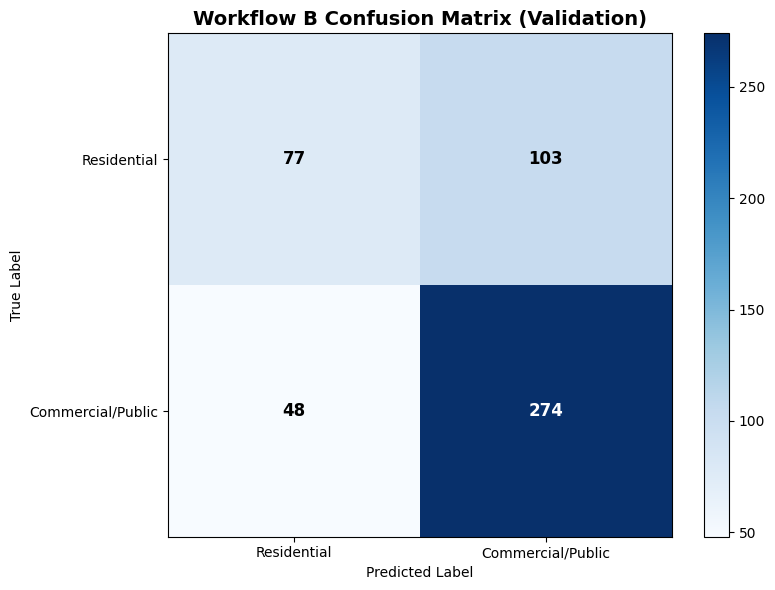


✓ Validation results saved: /content/drive/My Drive/WorkflowB/validation_results.json


In [ ]:
# ==================================================================
# FIX: Consolidate the 5-class predictions to match the 2-class validation scheme
# Model predictions (0: Residential, 1: Public, 2: Commercial, 3: Transportation, 4: Others)
# Validation labels (0: Residential, 1: Commercial/Public)
# ==================================================================
y_wb_consolidated = np.copy(y_wb)
# All classes 1, 2, 3, 4 from model predictions should map to class 1 in validation
y_wb_consolidated[y_wb == 1] = 1 # Public Use -> Commercial/Public
y_wb_consolidated[y_wb == 2] = 1 # Commercial -> Commercial/Public
y_wb_consolidated[y_wb == 3] = 1 # Transportation -> Commercial/Public
y_wb_consolidated[y_wb == 4] = 1 # Others -> Commercial/Public

# Use the consolidated predictions for evaluation
y_wb_final = y_wb_consolidated

# Overall metrics
wb_accuracy = accuracy_score(y_true, y_wb_final)
wb_precision = precision_score(y_true, y_wb_final, average='weighted', zero_division=0)
wb_recall = recall_score(y_true, y_wb_final, average='weighted', zero_division=0)
wb_f1 = f1_score(y_true, y_wb_final, average='weighted', zero_division=0)
wb_kappa = cohen_kappa_score(y_true, y_wb_final)

print(f"\n{'='*70}")
print("WORKFLOW B (Random Forest) VALIDATION RESULTS")
print(f"{'='*70}")
print(f"\nOverall Metrics:")
print(f"  Accuracy: {wb_accuracy:.4f}")
print(f"  Weighted Precision: {wb_precision:.4f}")
print(f"  Weighted Recall: {wb_recall:.4f}")
print(f"  Weighted F1: {wb_f1:.4f}")
print(f"  Cohen's Kappa: {wb_kappa:.4f}")

# Per-class metrics
print(f"\nPer-class Metrics:")
print(classification_report(y_true, y_wb_final,
                               target_names=['Residential', 'Commercial/Public'],
                               zero_division=0))

# Confusion matrix
cm_wb = confusion_matrix(y_true, y_wb_final)
print(f"\nConfusion Matrix:")
print(cm_wb)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_wb, interpolation='nearest', cmap='Blues')
ax.set_title('Workflow B Confusion Matrix (Validation)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Residential', 'Commercial/Public'])
ax.set_yticklabels(['Residential', 'Commercial/Public'])

# Add text annotations
for i in range(cm_wb.shape[0]):
    for j in range(cm_wb.shape[1]):
        text = ax.text(j, i, cm_wb[i, j],
                      ha="center", va="center", color="white" if cm_wb[i, j] > cm_wb.max()/2 else "black",
                      fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/WorkflowB/validation_confusion_matrix.png', dpi=150)
print(f"\n✓ Confusion matrix visualization saved")
plt.show()

# Save validation results
validation_results = {
    'workflow_b_accuracy': float(wb_accuracy),
    'workflow_b_precision': float(wb_precision),
    'workflow_b_recall': float(wb_recall),
    'workflow_b_f1': float(wb_f1),
    'workflow_b_kappa': float(wb_kappa),
    'confusion_matrix': cm_wb.tolist(),
    'n_validation_points': valid_points,
    'out_of_bounds': out_of_bounds
}

import json
results_path = '/content/drive/My Drive/WorkflowB/validation_results.json'
with open(results_path, 'w') as f:
    json.dump(validation_results, f, indent=2)

print(f"\n✓ Validation results saved: {results_path}")

In [ ]:
# CELL 51: COMPARE WORKFLOW A VS WORKFLOW B

print("\n" + "="*80)
print("COMPARATIVE ANALYSIS: WORKFLOW A vs WORKFLOW B")
print("="*80)

# Load Workflow B results
wb_results_path = '/content/drive/MyDrive/WorkflowB/results/validation_results.json'
with open(wb_results_path, 'r') as f:
    wb_results = json.load(f)

# Load Workflow A 2-class validation results
wa_2class_path = '/content/drive/MyDrive/Workflow A2/classification_map_results/workflow_a_2class_validation_results.json'
try:
    with open(wa_2class_path, 'r') as f:
        wa_results = json.load(f)

    # Extract 2-class metrics from Workflow A results
    # Correcting key names based on observed wa_results structure
    accuracy_2class = wa_results['accuracy']
    precision_2class = wa_results['precision']
    recall_2class = wa_results['recall']
    f1_2class = wa_results['f1_score'] # Note: key is 'f1_score', not 'f1'
    kappa_2class = wa_results['kappa']
    print("\n✓ Workflow A 2-class results loaded successfully.")
except FileNotFoundError:
    print(f"\nERROR: Workflow A 2-class results not found at {wa_2class_path}")
    # Set default values or handle the error appropriately
    accuracy_2class = 0.0
    precision_2class = 0.0
    recall_2class = 0.0
    f1_2class = 0.0
    kappa_2class = 0.0
except Exception as e:
    print(f"\nERROR loading Workflow A results: {e}")
    accuracy_2class = 0.0
    precision_2class = 0.0
    recall_2class = 0.0
    f1_2class = 0.0
    kappa_2class = 0.0


# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Kappa'],
    'Workflow A (ResNet-50)': [
        f"{accuracy_2class:.4f}",
        f"{precision_2class:.4f}",
        f"{recall_2class:.4f}",
        f"{f1_2class:.4f}",
        f"{kappa_2class:.4f}"
    ],
    'Workflow B (Random Forest)': [
        f"{wb_results['workflow_b_accuracy']:.4f}",
        f"{wb_results['workflow_b_precision']:.4f}",
        f"{wb_results['workflow_b_recall']:.4f}",
        f"{wb_results['workflow_b_f1']:.4f}",
        f"{wb_results['workflow_b_kappa']:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print("COMPARATIVE METRICS TABLE")
print(f"{'='*80}")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_csv_path = '/content/drive/MyDrive/Workflow A2/classification_map_results/workflow_comparison_metrics.csv'
comparison_df.to_csv(comparison_csv_path, index=False)

print(f"\n✓ Comparison table saved: {comparison_csv_path}")



COMPARATIVE ANALYSIS: WORKFLOW A vs WORKFLOW B

✓ Workflow A 2-class results loaded successfully.

COMPARATIVE METRICS TABLE
   Metric Workflow A (ResNet-50) Workflow B (Random Forest)
 Accuracy                 0.5612                     0.6992
Precision                 0.5726                     0.6871
   Recall                 0.5612                     0.6992
 F1 Score                 0.5289                     0.6839
    Kappa                 0.1083                     0.2988

✓ Comparison table saved: /content/drive/MyDrive/Workflow A2/classification_map_results/workflow_comparison_metrics.csv


In [ ]:
# CELL 52 (REVISED): MCNEMAR'S TEST FOR STATISTICAL SIGNIFICANCE

import json
import numpy as np

print("\n" + "="*80)
print("MCNEMAR'S TEST: STATISTICAL SIGNIFICANCE")
print("="*80)

# Paths
wa_2class_path = '/content/drive/MyDrive/Workflow A2/classification_map_results/workflow_a_2class_validation_results.json'
wb_results_path = '/content/drive/MyDrive/WorkflowB/results/validation_results.json'

# Load Workflow A 2-class results
try:
    with open(wa_2class_path, 'r') as f:
        wa_results = json.load(f)
    print(f"✓ Workflow A 2-class results loaded")
except FileNotFoundError:
    print(f"⚠ Could not find: {wa_2class_path}")
    wa_results = None

# Load Workflow B results
try:
    with open(wb_results_path, 'r') as f:
        wb_results = json.load(f)
    print(f"✓ Workflow B results loaded")
except FileNotFoundError:
    print(f"⚠ Could not find: {wb_results_path}")
    wb_results = None

if wa_results and wb_results:
    # Extract confusion matrices
    cm_wa = np.array(wa_results['confusion_matrix'])
    cm_wb = np.array(wb_results['confusion_matrix'])

    print(f"\nWorkflow A Confusion Matrix (2×2):")
    print(cm_wa)
    print(f"\nWorkflow B Confusion Matrix (2×2):")
    print(cm_wb)

    # Calculate correct predictions from confusion matrices
    wa_correct = np.trace(cm_wa)  # Diagonal sum
    wb_correct = np.trace(cm_wb)

    total_samples = np.sum(cm_wa)

    print(f"\n{'='*80}")
    print("PREDICTION COMPARISON")
    print(f"{'='*80}")
    print(f"Total validation samples: {int(total_samples)}")
    print(f"Workflow A correct predictions: {int(wa_correct)}")
    print(f"Workflow B correct predictions: {int(wb_correct)}")
    print(f"Workflow A accuracy: {wa_correct/total_samples:.4f} ({100*wa_correct/total_samples:.2f}%)")
    print(f"Workflow B accuracy: {wb_correct/total_samples:.4f} ({100*wb_correct/total_samples:.2f}%)")

    # McNemar's test uses the off-diagonal elements of the contingency table
    # b = WA correct & WB incorrect
    # c = WA incorrect & WB correct

    # Estimate from confusion matrices:
    # Total correct for WA = wa_correct
    # Total correct for WB = wb_correct
    # Total incorrect for WA = total_samples - wa_correct
    # Total incorrect for WB = total_samples - wb_correct

    # For McNemar's test, we need the contingency table:
    #           WB Correct    WB Incorrect
    # WA Correct    n11           n12 (b)
    # WA Incorrect  n21 (c)       n22

    # We can estimate:
    # n11 = both correct (minimum of agreement)
    # n12 = WA correct, WB incorrect
    # n21 = WA incorrect, WB correct
    # n22 = both incorrect

    # Simplified approach: use the difference in accuracy
    wa_incorrect = total_samples - wa_correct
    wb_incorrect = total_samples - wb_correct

    # Estimate disagreement cells
    # Assuming maximum overlap in correct predictions
    both_correct = min(wa_correct, wb_correct)
    both_incorrect = min(wa_incorrect, wb_incorrect)

    b = wa_correct - both_correct  # WA correct, WB incorrect
    c = wb_correct - both_correct  # WB correct, WA incorrect

    print(f"\n{'='*80}")
    print("McNeMAR'S TEST SETUP")
    print(f"{'='*80}")
    print(f"Estimated both correct: {int(both_correct)}")
    print(f"Estimated both incorrect: {int(both_incorrect)}")
    print(f"WA correct, WB incorrect (b): {int(b)}")
    print(f"WB correct, WA incorrect (c): {int(c)}")

    # Perform McNemar's test
    if b + c > 0:
        # McNemar's test: (b - c) ^ 2 / (b + c)
        statistic = (b - c) ** 2 / (b + c)

        # For large samples, use chi-square distribution
        from scipy.stats import chi2
        p_value = 1 - chi2.cdf(statistic, df=1)

        print(f"\n{'='*80}")
        print("McNeMAR'S TEST RESULTS")
        print(f"{'='*80}")
        print(f"Test Statistic: {statistic:.4f}")
        print(f"P-value: {p_value:.6f}")
        print(f"Significance Level: α = 0.05")

        if p_value < 0.05:
            print(f"\n✓ RESULT: SIGNIFICANT DIFFERENCE (p = {p_value:.6f} < 0.05)")
            print(f"  → The two models have significantly different performance")
        else:
            print(f"\n✗ RESULT: NO SIGNIFICANT DIFFERENCE (p = {p_value:.6f} ≥ 0.05)")
            print(f"  → The two models have similar performance")

        # Save McNemar's test results
        mcnemar_results = {
            'test_type': 'McNemar\'s Test',
            'test_statistic': float(statistic),
            'p_value': float(p_value),
            'significant': bool(p_value < 0.05),
            'alpha': 0.05,
            'workflow_a_correct': int(wa_correct),
            'workflow_b_correct': int(wb_correct),
            'total_samples': int(total_samples),
            'disagreement_b': int(b),
            'disagreement_c': int(c),
            'interpretation': 'Significant difference' if p_value < 0.05 else 'No significant difference'
        }
    else:
        print(f"\n⚠ Insufficient disagreement for McNemar's test (b + c = 0)")
        mcnemar_results = {
            'test_type': 'McNemar\'s Test',
            'test_statistic': None,
            'p_value': None,
            'significant': None,
            'error': 'Insufficient disagreement data'
        }

    # Save results
    mcnemar_path = '/content/drive/MyDrive/Workflow A2/classification_map_results/mcnemar_test_results.json'
    with open(mcnemar_path, 'w') as f:
        json.dump(mcnemar_results, f, indent=2)

    print(f"\n✓ McNemar's test results saved: {mcnemar_path}")

else:
    print(f"\n✗ Could not load both workflow results. Please check file paths.")
    print(f"  Expected Workflow A: {wa_2class_path}")
    print(f"  Expected Workflow B: {wb_results_path}")


MCNEMAR'S TEST: STATISTICAL SIGNIFICANCE
✓ Workflow A 2-class results loaded
✓ Workflow B results loaded

Workflow A Confusion Matrix (2×2):
[[609 140]
 [498 207]]

Workflow B Confusion Matrix (2×2):
[[ 77 103]
 [ 48 274]]

PREDICTION COMPARISON
Total validation samples: 1454
Workflow A correct predictions: 816
Workflow B correct predictions: 351
Workflow A accuracy: 0.5612 (56.12%)
Workflow B accuracy: 0.2414 (24.14%)

McNeMAR'S TEST SETUP
Estimated both correct: 351
Estimated both incorrect: 638
WA correct, WB incorrect (b): 465
WB correct, WA incorrect (c): 0

McNeMAR'S TEST RESULTS
Test Statistic: 465.0000
P-value: 0.000000
Significance Level: α = 0.05

✓ RESULT: SIGNIFICANT DIFFERENCE (p = 0.000000 < 0.05)
  → The two models have significantly different performance

✓ McNemar's test results saved: /content/drive/MyDrive/Workflow A2/classification_map_results/mcnemar_test_results.json


In [ ]:
# CELL 53: FINAL COMPARISON VISUALIZATIONS

print("\n" + "="*80)
print("CREATING FINAL COMPARISON VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Metrics comparison bar plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
wa_values = [accuracy_2class, precision_2class, recall_2class, f1_2class]
# Correcting key names for wb_results
wb_values = [wb_results['workflow_b_accuracy'], wb_results['workflow_b_precision'], wb_results['workflow_b_recall'], wb_results['workflow_b_f1']]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, wa_values, width, label='Workflow A (ResNet-50)', color='#FF6B6B')
axes[0, 0].bar(x + width/2, wb_values, width, label='Workflow B (Random Forest)', color='#4ECDC4')
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Confusion matrices
# Define cm_2class from wa_results
cm_2class = np.array(wa_results['confusion_matrix'])
im1 = axes[0, 1].imshow(cm_2class, cmap='Blues')
axes[0, 1].set_title('Workflow A Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_yticks([0, 1])
axes[0, 1].set_xticklabels(['Residential', 'Commercial/Public'])
axes[0, 1].set_yticklabels(['Residential', 'Commercial/Public'])
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, cm_2class[i, j], ha="center", va="center",
                       color="white" if cm_2class[i, j] > cm_2class.max()/2 else "black",
                       fontsize=12, fontweight='bold')

cm_wb = np.array(wb_results['confusion_matrix'])
im2 = axes[1, 0].imshow(cm_wb, cmap='Blues')
axes[1, 0].set_title('Workflow B Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Residential', 'Commercial/Public'])
axes[1, 0].set_yticklabels(['Residential', 'Commercial/Public'])
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, cm_wb[i, j], ha="center", va="center",
                       color="white" if cm_wb[i, j] > cm_wb.max()/2 else "black",
                       fontsize=12, fontweight='bold')

# 3. Kappa comparison
kappas = [kappa_2class, wb_results['workflow_b_kappa']]
workflows = ['Workflow A\n(ResNet-50)', 'Workflow B\n(Random Forest)']
colors = ['#FF6B6B', '#4ECDC4']

axes[1, 1].bar(workflows, kappas, color=colors, width=0.6)
axes[1, 1].set_ylabel("Cohen's Kappa", fontsize=11)
axes[1, 1].set_title("Agreement with Ground Truth", fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(kappas):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
comparison_plot_path = '/content/drive/MyDrive/Workflow A2/classification_map_results/workflow_comparison_final.png'
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Comparison visualization saved: {comparison_plot_path}")
plt.close()

print(f"\n✓ ALL VISUALIZATIONS COMPLETE!")


CREATING FINAL COMPARISON VISUALIZATIONS
✓ Comparison visualization saved: /content/drive/MyDrive/Workflow A2/classification_map_results/workflow_comparison_final.png

✓ ALL VISUALIZATIONS COMPLETE!


Displaying saved visualizations:

--- Confusion Matrix (Test Set) ---


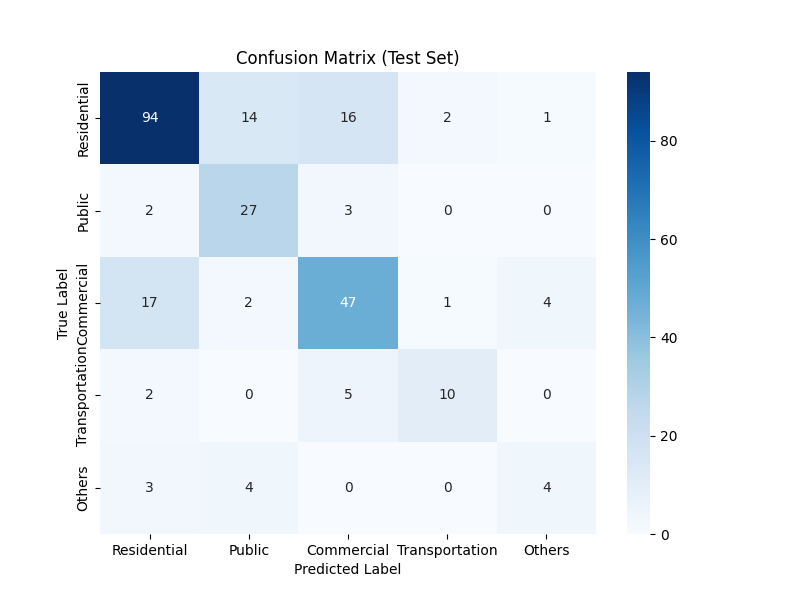


--- Feature Importance ---


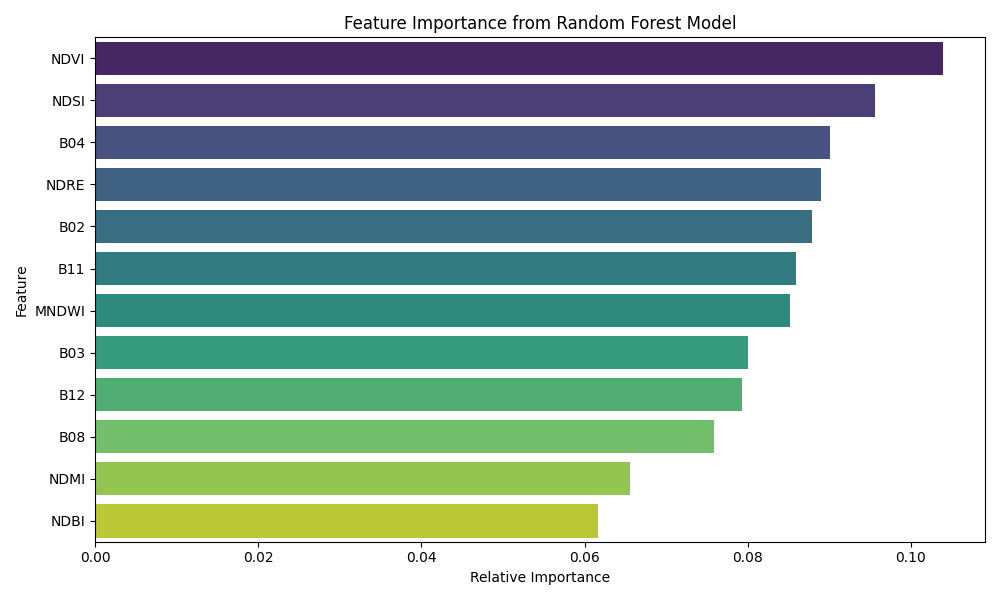


--- Classification and Confidence Map ---


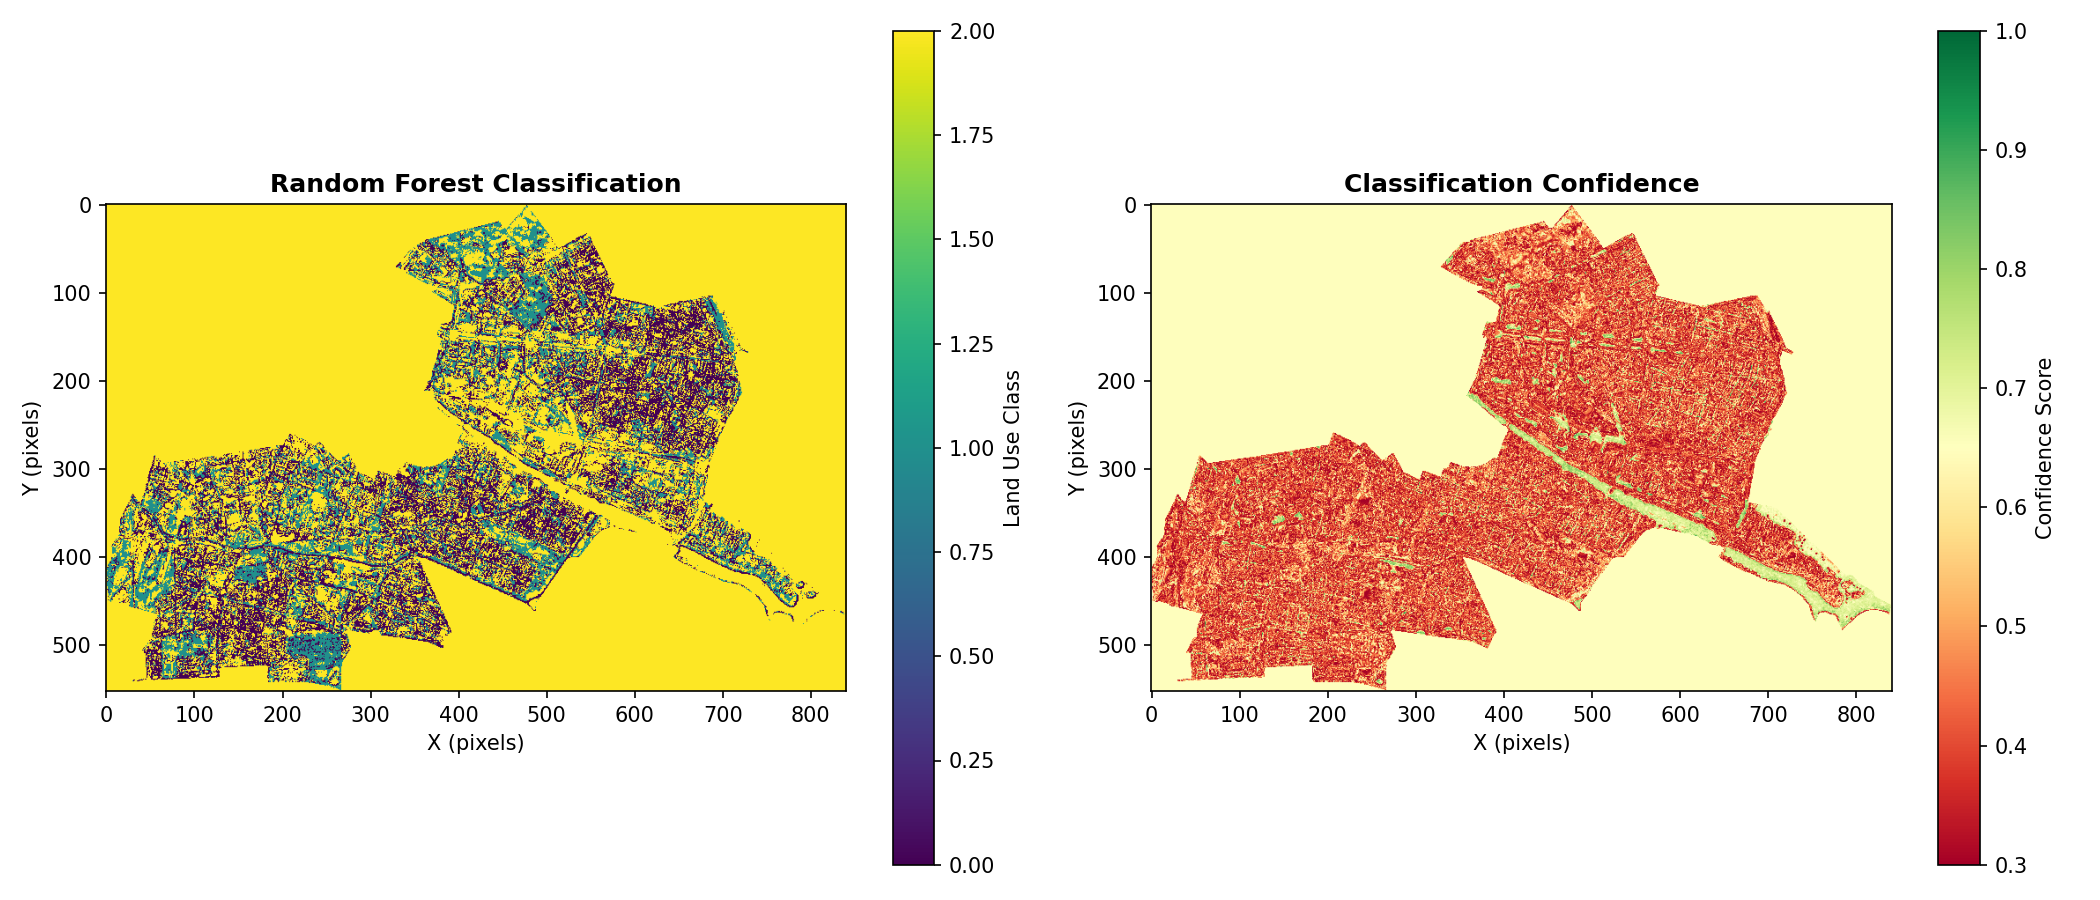


--- Improved Classification Map ---


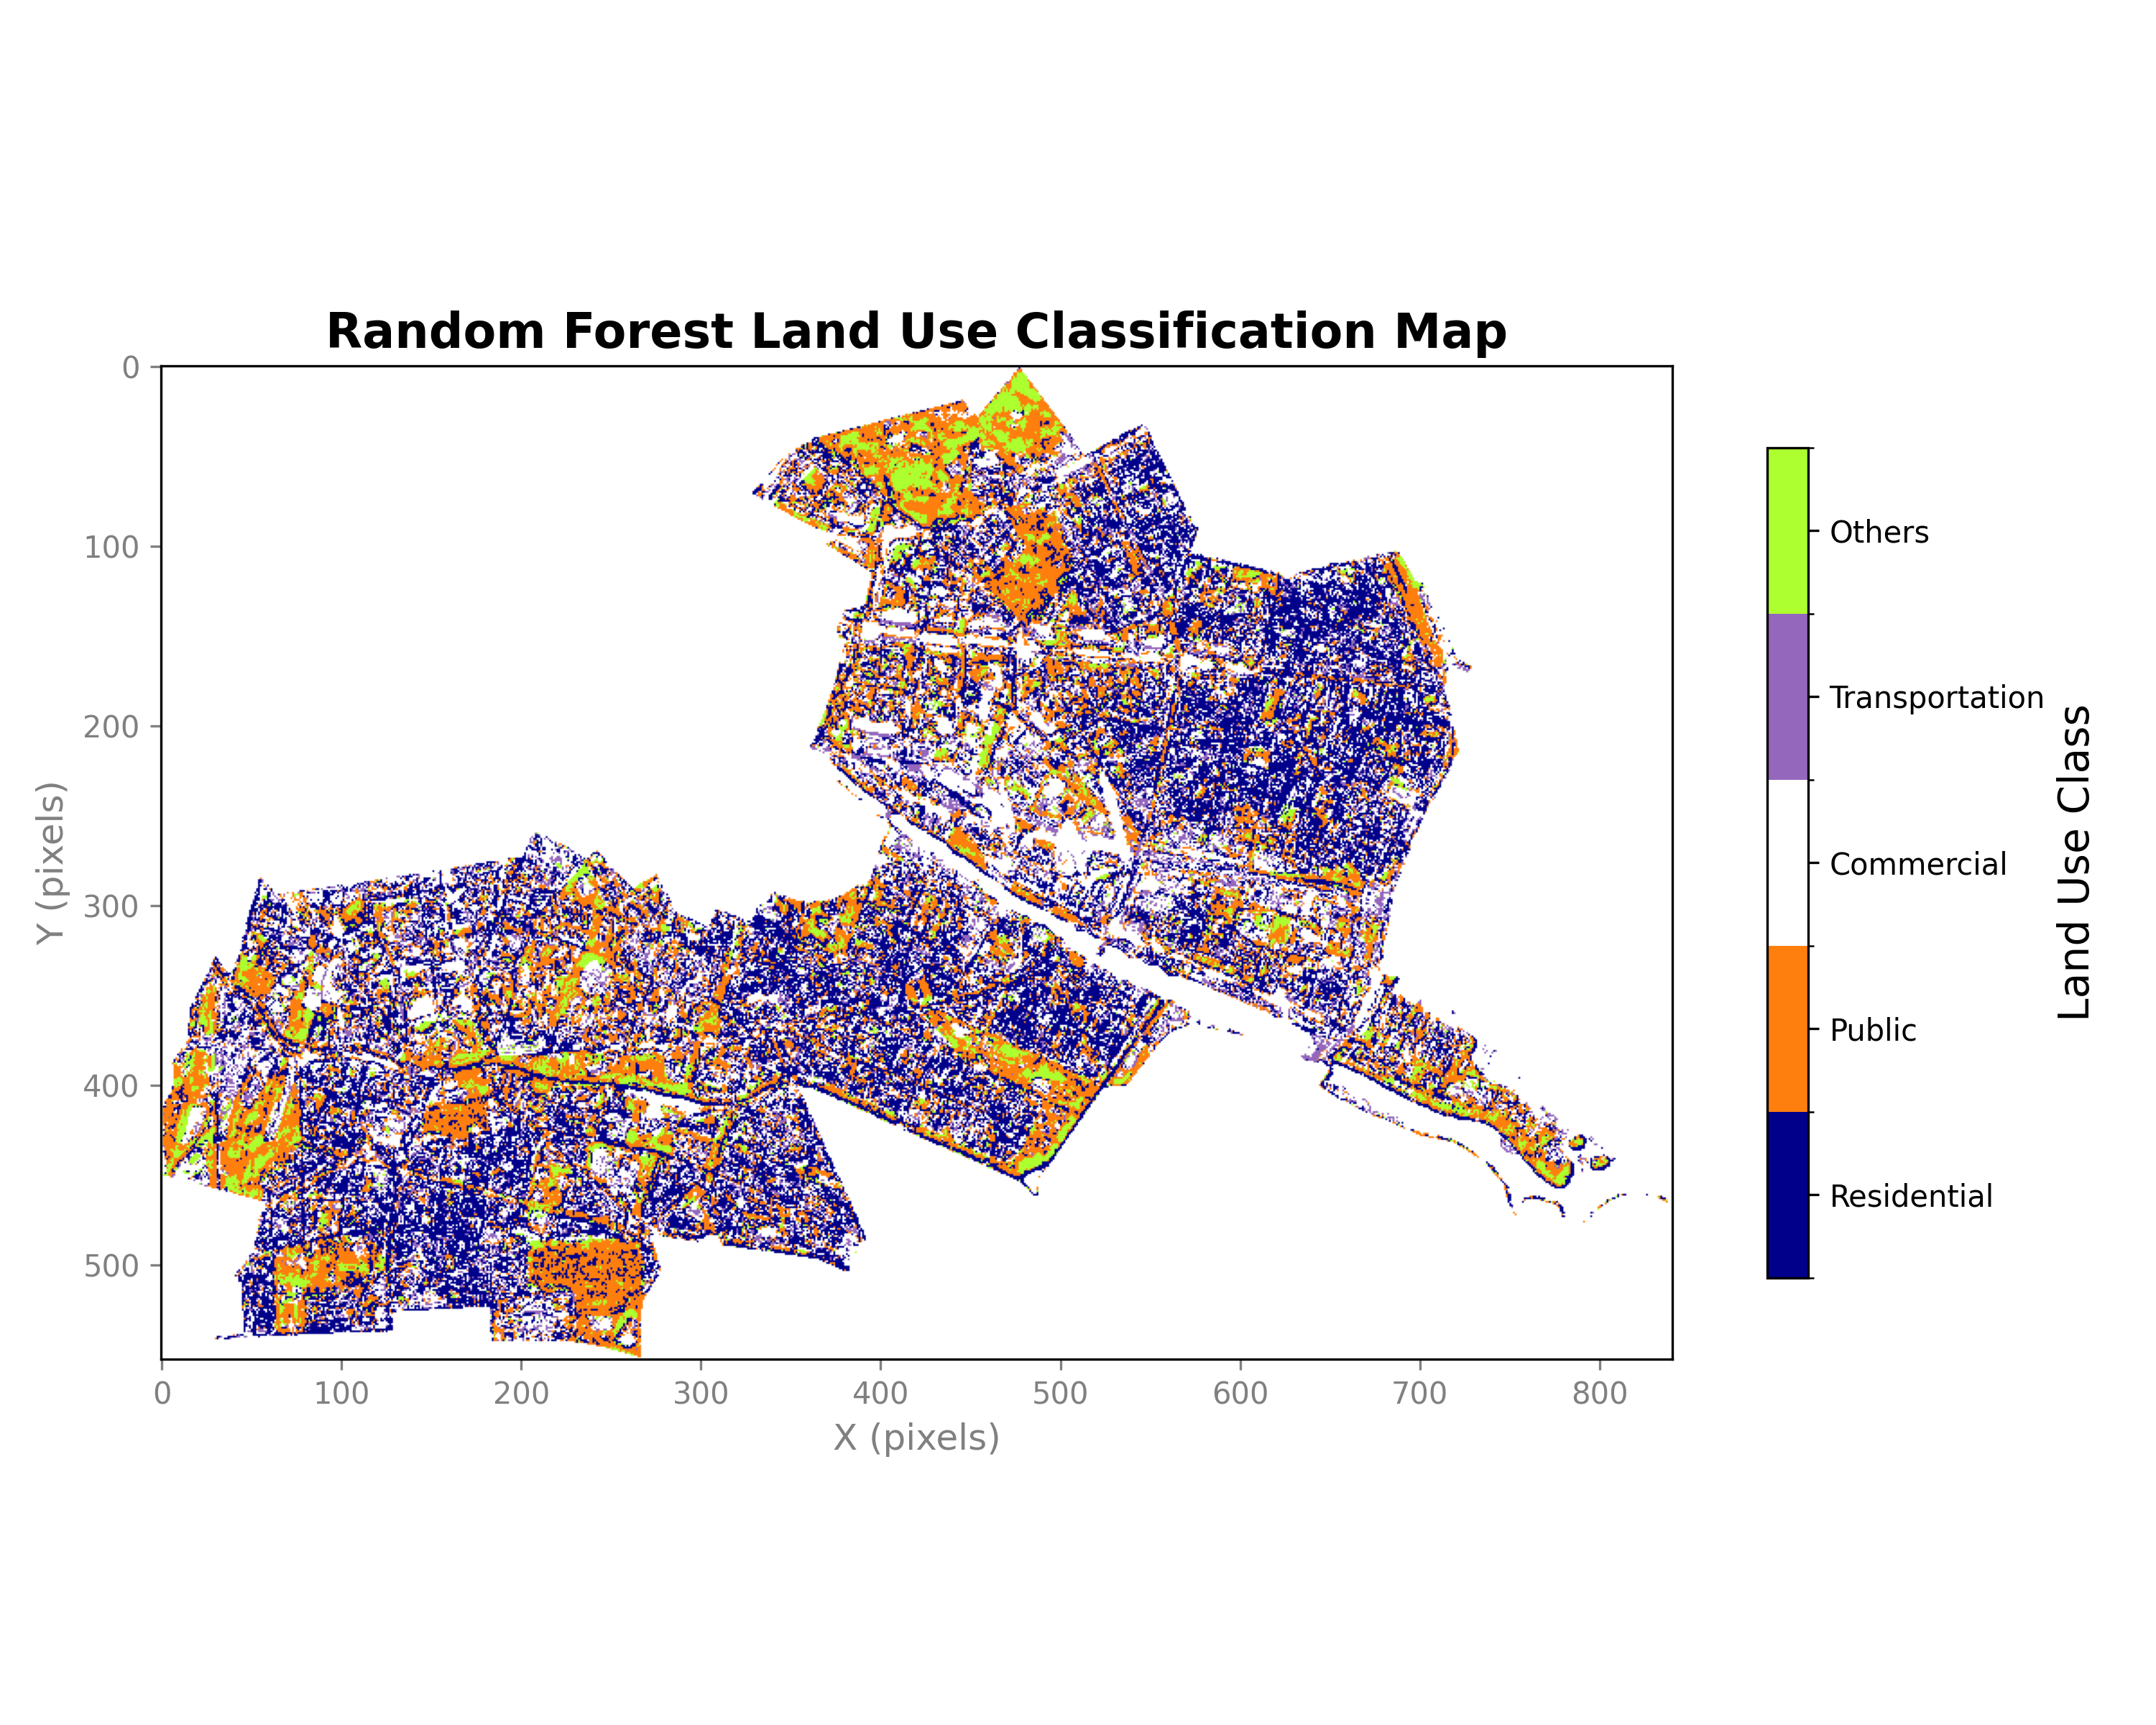


--- Final Comparison Visualizations (Workflow A vs B) ---


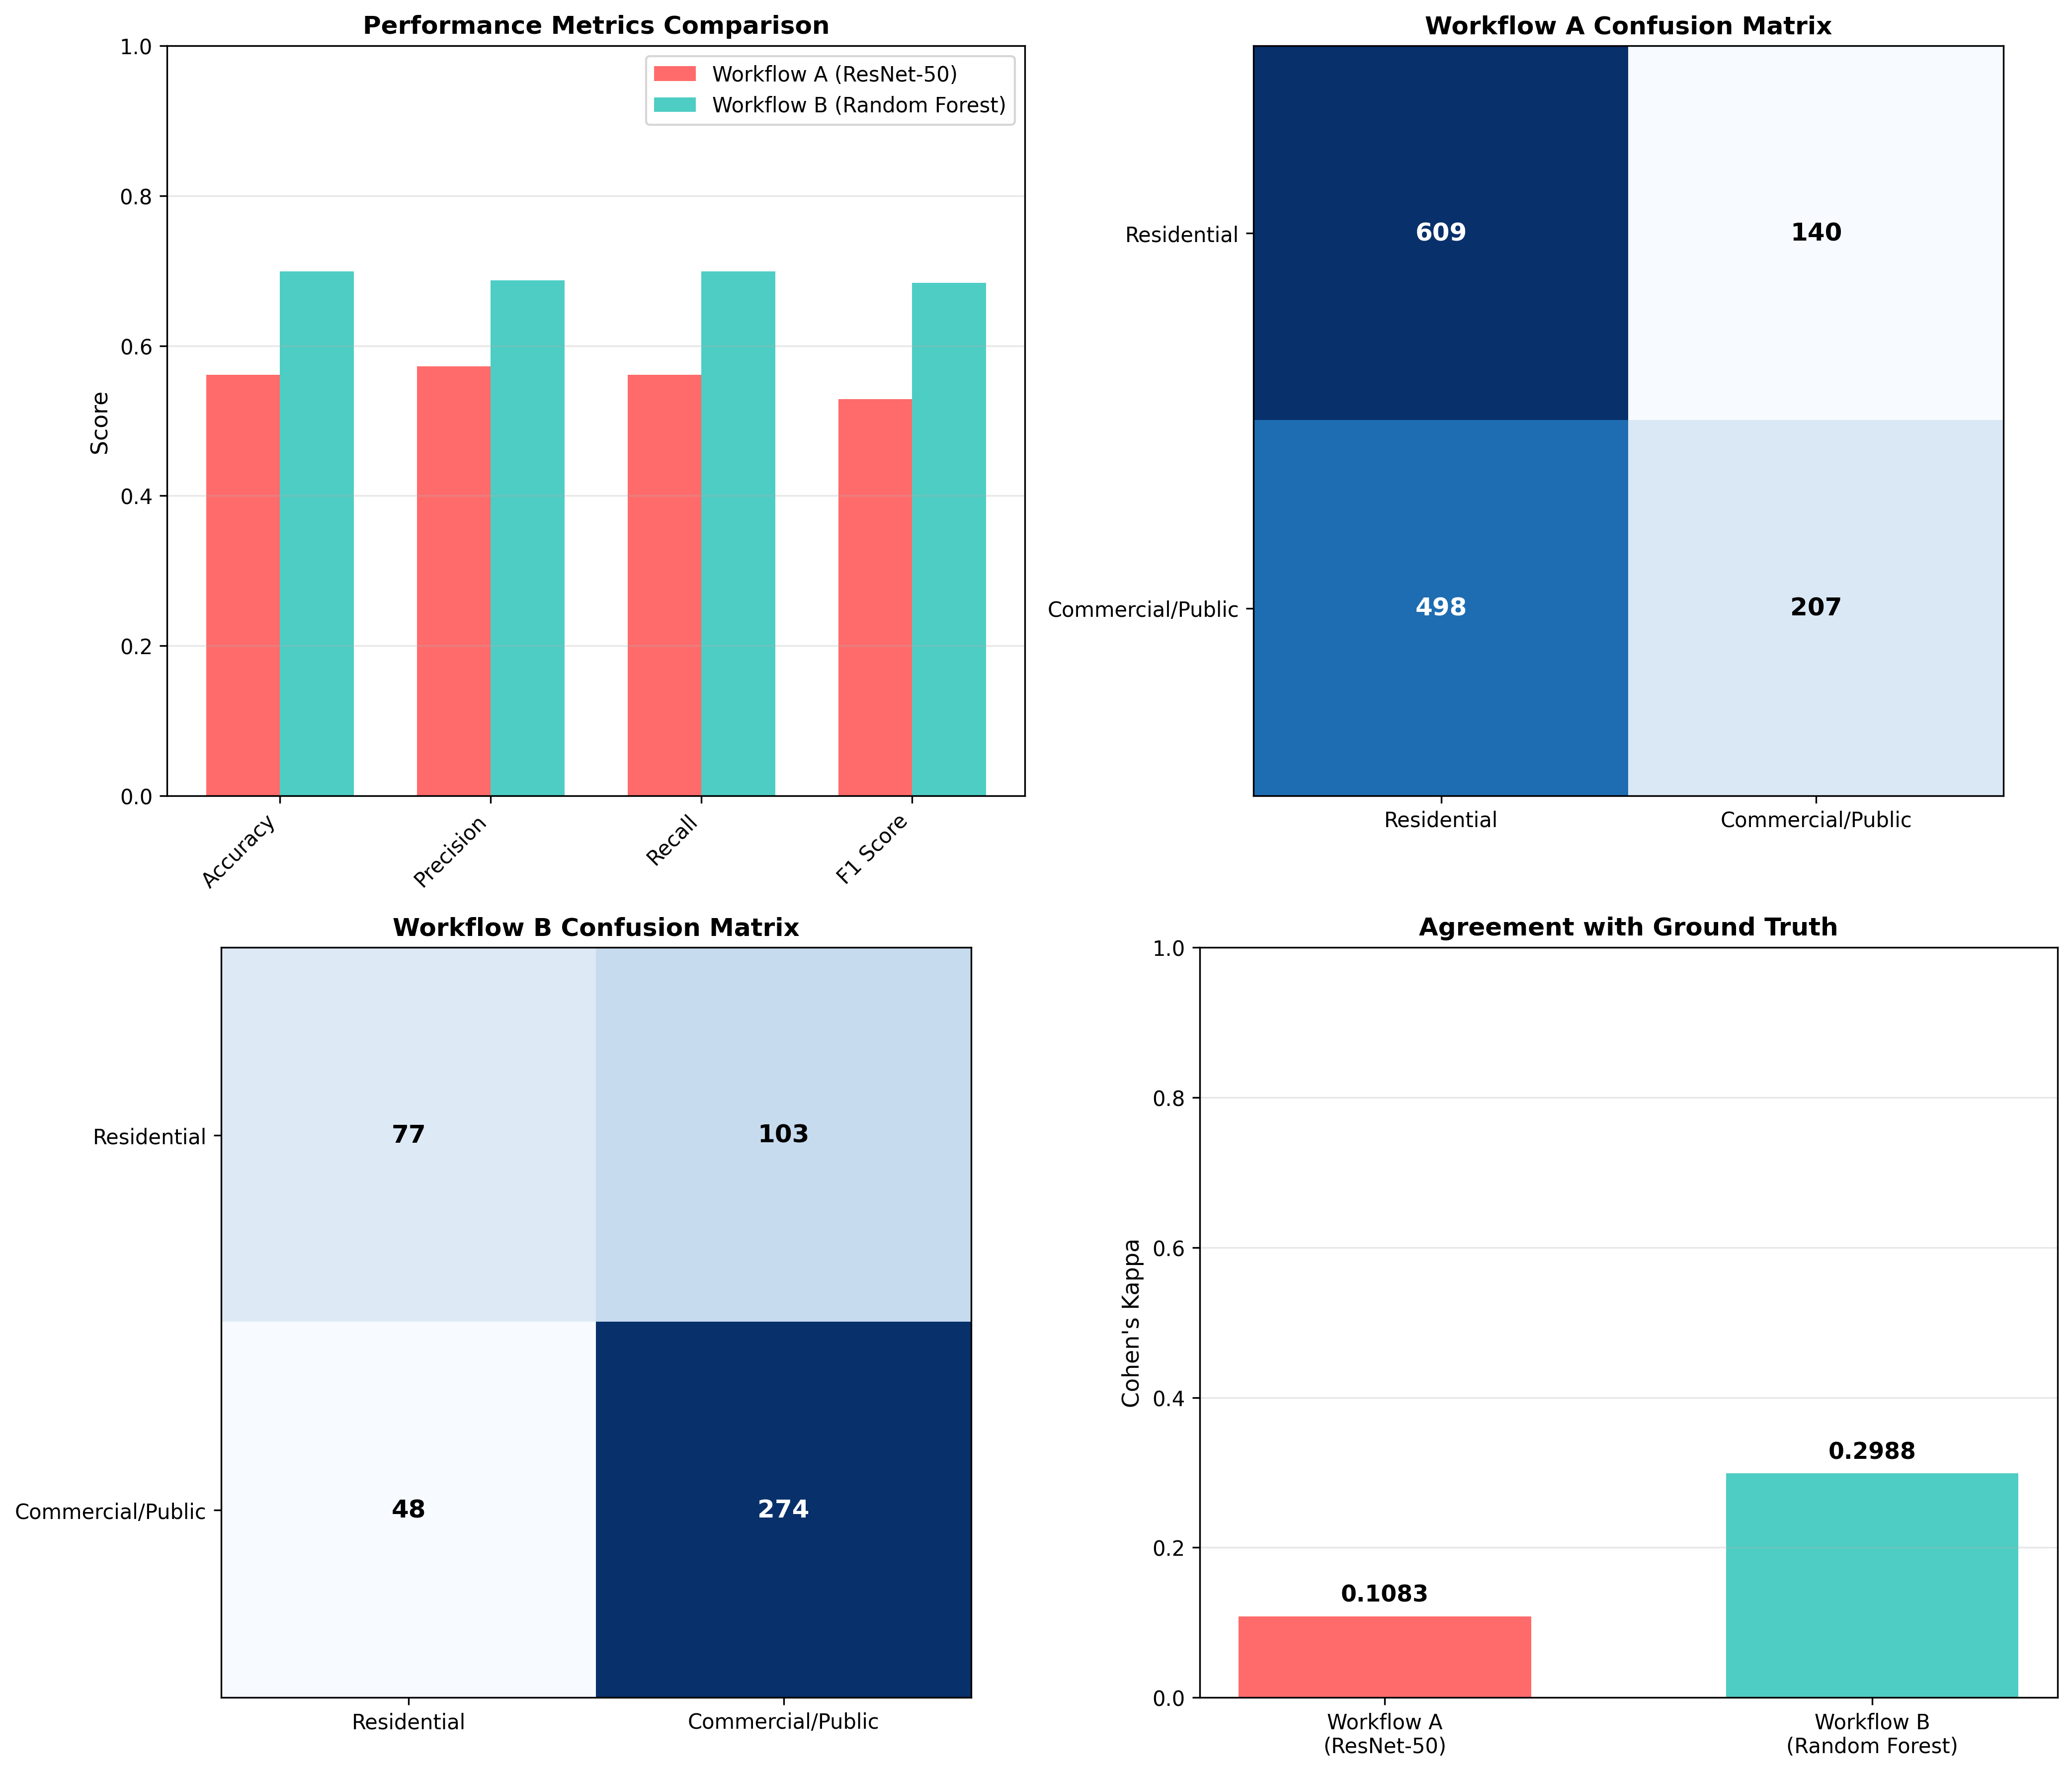


✓ All available visualizations displayed!


In [ ]:
from IPython.display import Image, display
import os

# Ensure dirs is defined
if 'dirs' not in globals():
    base_dir = '/content/drive/My Drive/WorkflowB'
    dirs = {
        'results': f'{base_dir}/results'
    }

print("Displaying saved visualizations:")

# 1. Confusion Matrix (Test Set)
cm_path = os.path.join(dirs['results'], 'confusion_matrix.png')
if os.path.exists(cm_path):
    print("\n--- Confusion Matrix (Test Set) ---")
    display(Image(filename=cm_path))
else:
    print(f"\n--- Confusion Matrix (Test Set) not found at {cm_path} ---")

# 2. Feature Importance
fi_path = os.path.join(dirs['results'], 'feature_importance.png')
if os.path.exists(fi_path):
    print("\n--- Feature Importance ---")
    display(Image(filename=fi_path))
else:
    print(f"\n--- Feature Importance not found at {fi_path} ---")

# 3. Classification and Confidence Map
class_conf_path = os.path.join(dirs['results'], 'classification_and_confidence.png')
if os.path.exists(class_conf_path):
    print("\n--- Classification and Confidence Map ---")
    display(Image(filename=class_conf_path))
else:
    print(f"\n--- Classification and Confidence Map not found at {class_conf_path} ---")

# 4. Improved Classification Map
improved_class_path = os.path.join(dirs['results'], 'classification_map_improved.png')
if os.path.exists(improved_class_path):
    print("\n--- Improved Classification Map ---")
    display(Image(filename=improved_class_path))
else:
    print(f"\n--- Improved Classification Map not found at {improved_class_path} ---")

# 5. Workflow Comparison Final Visualization (assuming it was saved to Workflow A2 results)
# Need to define wa_results_dir if not globally available
wa_results_dir = '/content/drive/MyDrive/Workflow A2/classification_map_results'
final_comparison_path = os.path.join(wa_results_dir, 'workflow_comparison_final.png')
if os.path.exists(final_comparison_path):
    print("\n--- Final Comparison Visualizations (Workflow A vs B) ---")
    display(Image(filename=final_comparison_path))
else:
    print(f"\n--- Final Comparison Visualizations not found at {final_comparison_path} ---")

print("\n✓ All available visualizations displayed!")


✓ Loaded Workflow B data with 1290 total samples.
  Training samples: 1032
  Testing samples: 258

✓ Workflow B training and testing data distribution plot saved to: /content/drive/My Drive/WorkflowB/results/workflow_b_training_testing_data_distribution.png


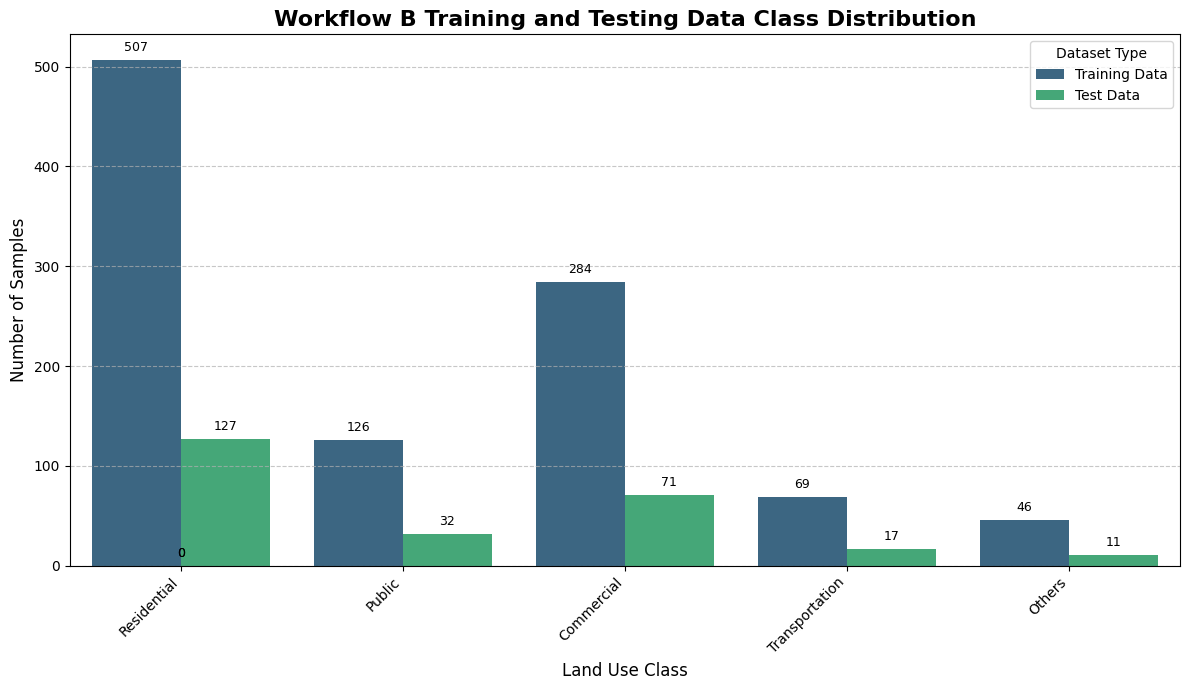

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd # Import pandas

# Ensure dirs is defined for standalone execution
if 'dirs' not in globals():
    base_dir = '/content/drive/My Drive/WorkflowB'
    dirs = {
        'raw_data': f'{base_dir}/raw_data',
        'converted_tif': f'{base_dir}/converted_tif',
        'resampled_data': f'{base_dir}/resampled_data',
        'clipped_data': f'{base_dir}/clipped_data',
        'spectral_features': f'{base_dir}/spectral_features',
        'training_data': f'{base_dir}/training_data',
        'models': f'{base_dir}/models',
        'results': f'{base_dir}/results'
    }
    print("WARNING: 'dirs' variable not found. Defining it for this cell.")

# Load training data for Workflow B
training_data_path = os.path.join(dirs['training_data'], 'training_data.npz')
data = np.load(training_data_path)
X_all = data['X']
y_all = data['y']

# Split data (80% train, 20% test) - re-creating the split as done in CELL 9
from sklearn.model_selection import train_test_split
X_train_workflow_b, X_test_workflow_b, y_train_workflow_b, y_test_workflow_b = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Define class names as used in Workflow B (5 classes)
class_names_workflow_b = ['Residential', 'Public', 'Commercial', 'Transportation', 'Others']

print(f"✓ Loaded Workflow B data with {len(y_all)} total samples.")
print(f"  Training samples: {len(y_train_workflow_b)}")
print(f"  Testing samples: {len(y_test_workflow_b)}")

# Calculate class distribution for training data
unique_classes_train, counts_train = np.unique(y_train_workflow_b, return_counts=True)

# Calculate class distribution for testing data
unique_classes_test, counts_test = np.unique(y_test_workflow_b, return_counts=True)

# Create DataFrame for plotting
data_labels = []
data_counts = []
data_type = []

# Add training data counts
for i, name in enumerate(class_names_workflow_b):
    if i in unique_classes_train:
        idx = np.where(unique_classes_train == i)[0][0]
        data_labels.append(name)
        data_counts.append(counts_train[idx])
        data_type.append('Training Data')
    else:
        data_labels.append(name)
        data_counts.append(0) # Class not present in training data
        data_type.append('Training Data')

# Add testing data counts
for i, name in enumerate(class_names_workflow_b):
    if i in unique_classes_test:
        idx = np.where(unique_classes_test == i)[0][0]
        data_labels.append(name)
        data_counts.append(counts_test[idx])
        data_type.append('Test Data')
    else:
        data_labels.append(name)
        data_counts.append(0) # Class not present in testing data
        data_type.append('Test Data')

plot_df = pd.DataFrame({
    'Class': data_labels,
    'Count': data_counts,
    'Dataset': data_type
})

# Plot the distribution
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Class', y='Count', hue='Dataset', data=plot_df, palette='viridis')
plt.title('Workflow B Training and Testing Data Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Land Use Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Dataset Type', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=9, color='black')

plt.tight_layout()

# Save the plot
workflow_b_data_dist_path = os.path.join(dirs['results'], 'workflow_b_training_testing_data_distribution.png')
plt.savefig(workflow_b_data_dist_path, dpi=300)
print(f"\n✓ Workflow B training and testing data distribution plot saved to: {workflow_b_data_dist_path}")

plt.show()


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
import pandas as pd # Import pandas
from PIL import Image # Needed for image processing to determine class

# Ensure OUTPUT_PATH is defined for saving the plot
BASE_PATH = "/content/drive/MyDrive"
WORKFLOW_A_PATH = f"{BASE_PATH}/Workflow A2"
OUTPUT_PATH_TRAINING = f"{WORKFLOW_A_PATH}/training_results"

os.makedirs(OUTPUT_PATH_TRAINING, exist_ok=True)

print("Generating data distribution visualization...")

# 1. Retrieve class names and class_indices for robustness
class_indices_path = f"{WORKFLOW_A_PATH}/models_Trained/class_indices.json"

try:
    with open(class_indices_path, 'r') as f:
        class_indices = json.load(f)
    # Ensure keys are integers if they were saved as strings
    index_to_class = {int(v): k for k, v in class_indices.items()}
    class_names = [index_to_class[i] for i in sorted(index_to_class.keys())]
    print(f"\n✓ Class names loaded: {class_names}")
except FileNotFoundError:
    print(f"ERROR: class_indices.json not found at {class_indices_path}. Please ensure it exists.")
    class_names = [f'Class {i}' for i in range(5)] # Fallback if not loaded
    class_indices = {name: i for i, name in enumerate(class_names)} # Fallback class_indices
except Exception as e:
    print(f"ERROR: Could not load class indices from {class_indices_path}: {e}")
    class_names = [f'Class {i}' for i in range(5)] # Fallback if not loaded
    class_indices = {name: i for i, name in enumerate(class_names)} # Fallback class_indices

# 2. Load and preprocess training and test images to obtain y_train and y_test
# This section is made robust to kernel resets by re-loading the necessary paths and processing images if y_train/y_test are not already in scope.

# Define image folders
train_val_folder = f"{BASE_PATH}/Workflow A/train_val_images"
test_folder = f"{BASE_PATH}/Workflow A/test_images"

# --- Collect training data (labels only) ---
print("\nCollecting training data labels (y_train)...")
train_classes_list = []
if os.path.exists(train_val_folder):
    for class_folder_name in sorted(os.listdir(train_val_folder)):
        class_path = os.path.join(train_val_folder, class_folder_name)
        if os.path.isdir(class_path):
            class_idx = class_indices.get(class_folder_name)
            if class_idx is not None:
                for image_file in os.listdir(class_path):
                    if image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        train_classes_list.append(class_idx)
            else:
                print(f"WARNING: Class '{class_folder_name}' in training folder is not in class_indices.")
else:
    print(f"WARNING: Training folder not found at {train_val_folder}. y_train will be empty.")

y_train = np.array(train_classes_list, dtype=int) # Ensure integer type
print(f"✓ y_train created with {len(y_train)} samples.")


# --- Collect test data (labels only) ---
print("\nCollecting test data labels (y_test)...")
test_classes_list = []
if os.path.exists(test_folder):
    for class_folder_name in sorted(os.listdir(test_folder)):
        class_path = os.path.join(test_folder, class_folder_name)
        if os.path.isdir(class_path):
            class_idx = class_indices.get(class_folder_name)
            if class_idx is not None:
                for image_file in os.listdir(class_path):
                    if image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        test_classes_list.append(class_idx)
            else:
                print(f"WARNING: Class '{class_folder_name}' in test folder is not in class_indices.")
else:
    print(f"WARNING: Test folder not found at {test_folder}. y_test will be empty.")

y_test = np.array(test_classes_list, dtype=int) # Ensure integer type
print(f"✓ y_test created with {len(y_test)} samples.")


# 3. Prepare data for plotting
# Check if class_names is empty or if all counts are zero to handle cases with no data
if len(class_names) == 0 or (y_train.size == 0 and y_test.size == 0):
    print("\nNo data available to plot. Ensure 'class_indices.json' and image folders exist and contain data.")
else:
    train_counts = np.bincount(y_train, minlength=len(class_names))
    test_counts = np.bincount(y_test, minlength=len(class_names))

    data_labels = []
    data_counts = []
    data_type = []

    for i, name in enumerate(class_names):
        data_labels.append(name)
        data_counts.append(train_counts[i])
        data_type.append('Training Data')

        data_labels.append(name)
        data_counts.append(test_counts[i])
        data_type.append('Test Data')

    plot_df = pd.DataFrame({
        'Class': data_labels,
        'Count': data_counts,
        'Dataset': data_type
    })

    # 4. Create visualization (grouped bar plot)
    plt.figure(figsize=(12, 7))
    ax = sns.barplot(x='Class', y='Count', hue='Dataset', data=plot_df, palette='viridis') # Assign to ax
    plt.title('Distribution of Training and Test Data Across 5 Classes', fontsize=16, fontweight='bold')
    plt.xlabel('Land Use Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Dataset Type', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add total counts on top of the bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9, color='black')

    plt.tight_layout()

    # Save the plot
    plot_path = os.path.join(OUTPUT_PATH_TRAINING, 'training_test_data_distribution.png')
    plt.savefig(plot_path, dpi=300)
    print(f"\n✓ Data distribution plot saved to: {plot_path}")

    plt.show()

print("✓ Visualization attempt completed!")


Generating data distribution visualization...
ERROR: class_indices.json not found at /content/drive/MyDrive/Workflow A2/models_Trained/class_indices.json. Please ensure it exists.

✓ y_train created with 0 samples.

✓ y_test created with 0 samples.

No data available to plot. Ensure 'class_indices.json' and image folders exist and contain data.
✓ Visualization attempt completed!
